#Part 1: LPA Input Variables Exploration

## 1.1 Data Quality & Distribution Assessment
Purpose: Validate preprocessing pipeline and identify data quality issues


In [ ]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MIDUS 2/Data/processed_midus_data.csv')

### Univariate Distributions

In [ ]:
def plot_input_distributions(df, variables, title_prefix=""):
    """
    Plot distribution for each LPA input variable
    """
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 3, figsize=(15, 4*n_vars))

    for i, var in enumerate(variables):
        # Histogram with KDE
        axes[i, 0].hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i, 0].set_title(f'{var} - Histogram')
        axes[i, 0].set_xlabel(var)
        axes[i, 0].set_ylabel('Frequency')

        # KDE plot
        df[var].dropna().plot(kind='kde', ax=axes[i, 1])
        axes[i, 1].set_title(f'{var} - Density')
        axes[i, 1].set_xlabel(var)

        # Q-Q plot for normality
        stats.probplot(df[var].dropna(), dist="norm", plot=axes[i, 2])
        axes[i, 2].set_title(f'{var} - Q-Q Plot')

    plt.tight_layout()
    plt.savefig(f'{title_prefix}_input_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()


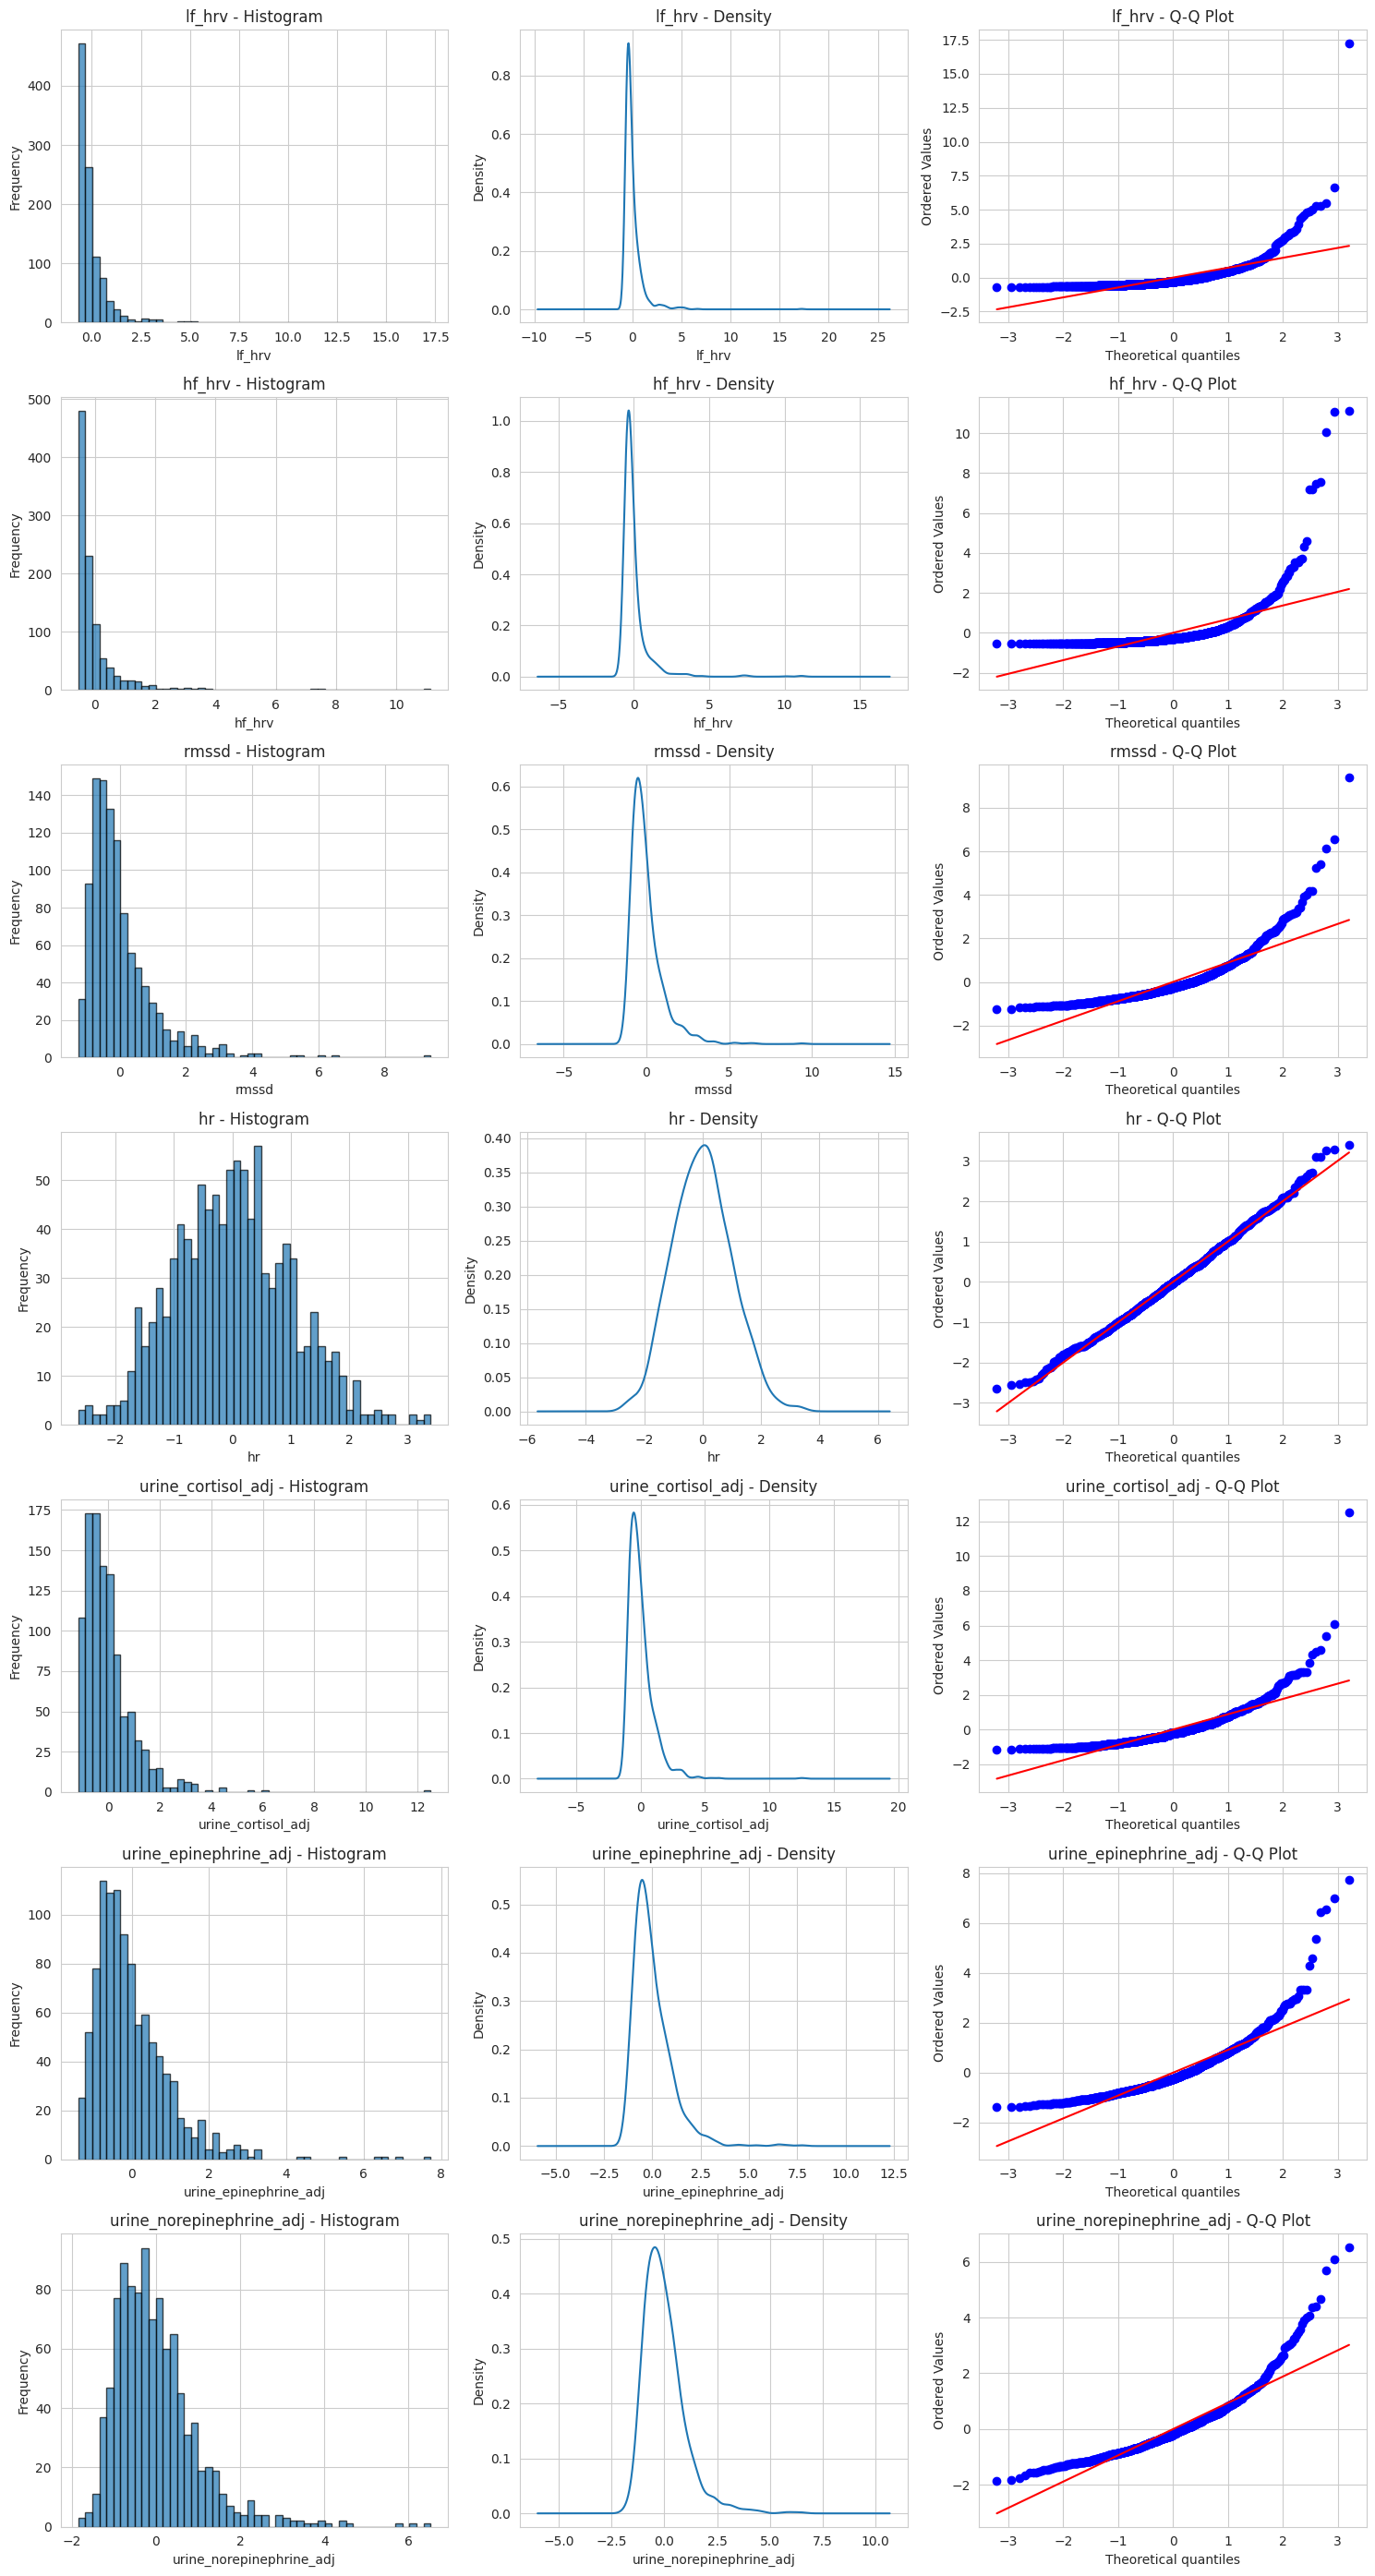

In [ ]:
# continuous indicators
lpa_input_vars = ['lf_hrv',
                        'hf_hrv',
                        'rmssd',
                        'hr',
                        'urine_cortisol_adj',
                        'urine_epinephrine_adj',
                        'urine_norepinephrine_adj']
# continuous outcome variables(no cardiovascular disease risk)
outcome_varialbes = [
                     'anxiety',
                     'distress_anxious',
                     'anger',
                     'depression',
                     'phys_hlth_evnts_tot',
                     'cvd_risk'
                     ]
plot_input_distributions(data, lpa_input_vars, "LPA_Inputs")

### Summary Statistics Table

In [ ]:
def create_summary_stats(df, variables):
    """
    Comprehensive summary statistics for LPA inputs
    """
    summary = pd.DataFrame({
        'Variable': variables,
        'N': [df[var].notna().sum() for var in variables],
        'N_Missing': [df[var].isna().sum() for var in variables],
        'Pct_Missing': [df[var].isna().sum() / len(df) * 100 for var in variables],
        'Mean': [df[var].mean() for var in variables],
        'Median': [df[var].median() for var in variables],
        'SD': [df[var].std() for var in variables],
        'Min': [df[var].min() for var in variables],
        'Max': [df[var].max() for var in variables],
        'Q1': [df[var].quantile(0.25) for var in variables],
        'Q3': [df[var].quantile(0.75) for var in variables],
        'IQR': [df[var].quantile(0.75) - df[var].quantile(0.25) for var in variables],
        'Skewness': [df[var].skew() for var in variables],
        'Kurtosis': [df[var].kurtosis() for var in variables],
        'N_Outliers': [len(df[(df[var] < df[var].quantile(0.25) - 1.5*stats.iqr(df[var].dropna())) |
                              (df[var] > df[var].quantile(0.75) + 1.5*stats.iqr(df[var].dropna()))])
                       for var in variables]
    })

    return summary.round(3)

summary_stats = create_summary_stats(data, lpa_input_vars)
print(summary_stats.to_string())
summary_stats.to_csv('lpa_input_summary_statistics.csv', index=False)

                   Variable     N  N_Missing  Pct_Missing  Mean  Median   SD    Min     Max     Q1     Q3    IQR  Skewness  Kurtosis  N_Outliers
0                    lf_hrv  1030          0          0.0  -0.0  -0.288  1.0 -0.691  17.254 -0.500  0.133  0.633     6.990    92.611          73
1                    hf_hrv  1030          0          0.0   0.0  -0.286  1.0 -0.553  11.137 -0.447  0.019  0.466     6.032    50.794         107
2                     rmssd  1030          0          0.0   0.0  -0.255  1.0 -1.255   9.379 -0.641  0.310  0.951     2.669    13.023          62
3                        hr  1030          0          0.0   0.0  -0.021  1.0 -2.639   3.390 -0.711  0.645  1.356     0.211    -0.004           6
4        urine_cortisol_adj  1030          0          0.0   0.0  -0.224  1.0 -1.167  12.510 -0.662  0.355  1.017     3.341    26.931          44
5     urine_epinephrine_adj  1030          0          0.0  -0.0  -0.245  1.0 -1.383   7.726 -0.667  0.428  1.096     2.292    10.1

### Correlation Matrix

In [ ]:
def plot_correlation_heatmap(df, variables, title=""):
    """
    Visualize correlations between LPA input variables
    """
    corr_matrix = df[variables].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(f'{title} - Correlation Matrix', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.savefig(f'{title}_correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    return corr_matrix



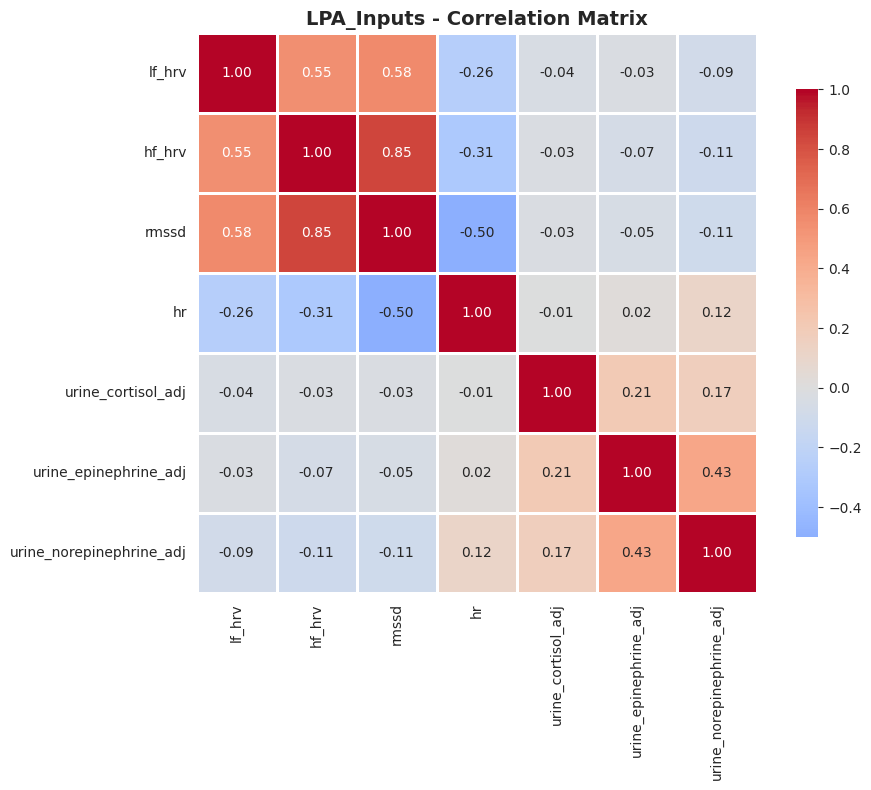

In [ ]:
corr_matrix = plot_correlation_heatmap(data, lpa_input_vars, "LPA_Inputs")

### Outlier Detection & Visualization

In [ ]:
def plot_boxplots_with_outliers(df, variables, title_prefix=""):
    """
    Boxplots to identify outliers in input variables
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    for i, var in enumerate(variables):
        axes[i].boxplot(df[var].dropna(), vert=True)
        axes[i].set_title(var)
        axes[i].set_ylabel('Value')

        # Mark outliers
        Q1 = df[var].quantile(0.25)
        Q3 = df[var].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[var] < Q1 - 1.5*IQR) | (df[var] > Q3 + 1.5*IQR)][var]
        axes[i].text(0.5, 0.95, f'Outliers: {len(outliers)}',
                    transform=axes[i].transAxes, ha='center', va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig(f'{title_prefix}_outlier_boxplots.png', dpi=300, bbox_inches='tight')
    plt.show()



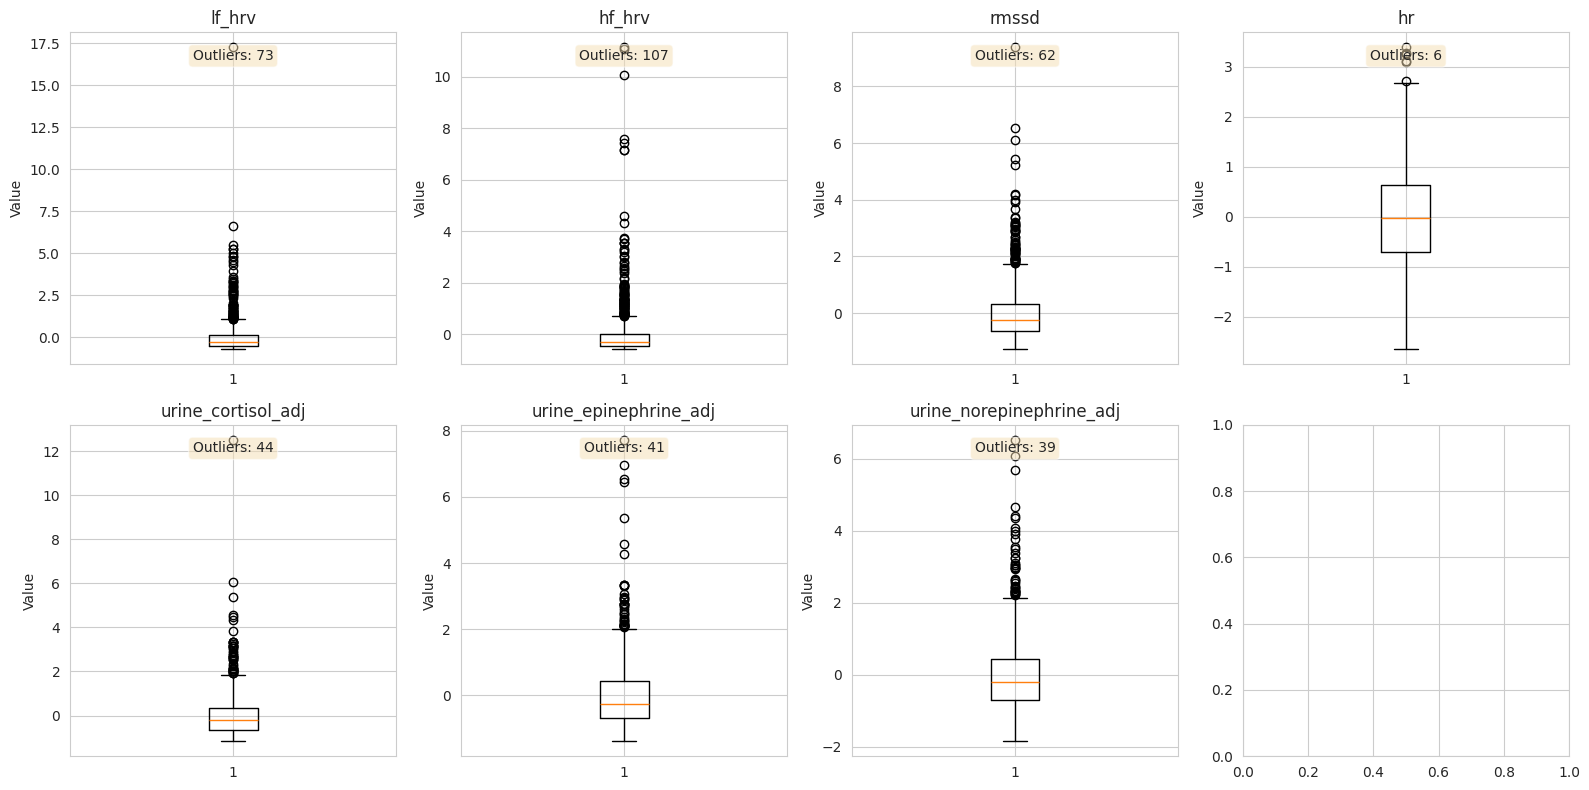

In [ ]:
plot_boxplots_with_outliers(data, lpa_input_vars, "LPA_Inputs")

### Pairwise Scatter Plots

In [ ]:
def plot_pairwise_scatters(df, variables, sample_size=1000):
    """
    Pairwise scatter plots for multivariate relationships
    """
    # Sample for visualization if dataset is large
    if len(df) > sample_size:
        df_sample = df[variables].sample(n=sample_size, random_state=42)
    else:
        df_sample = df[variables]

    g = sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
    g.fig.suptitle('Pairwise Relationships - LPA Input Variables', y=1.01)
    plt.savefig('lpa_inputs_pairplot.png', dpi=300, bbox_inches='tight')
    plt.show()



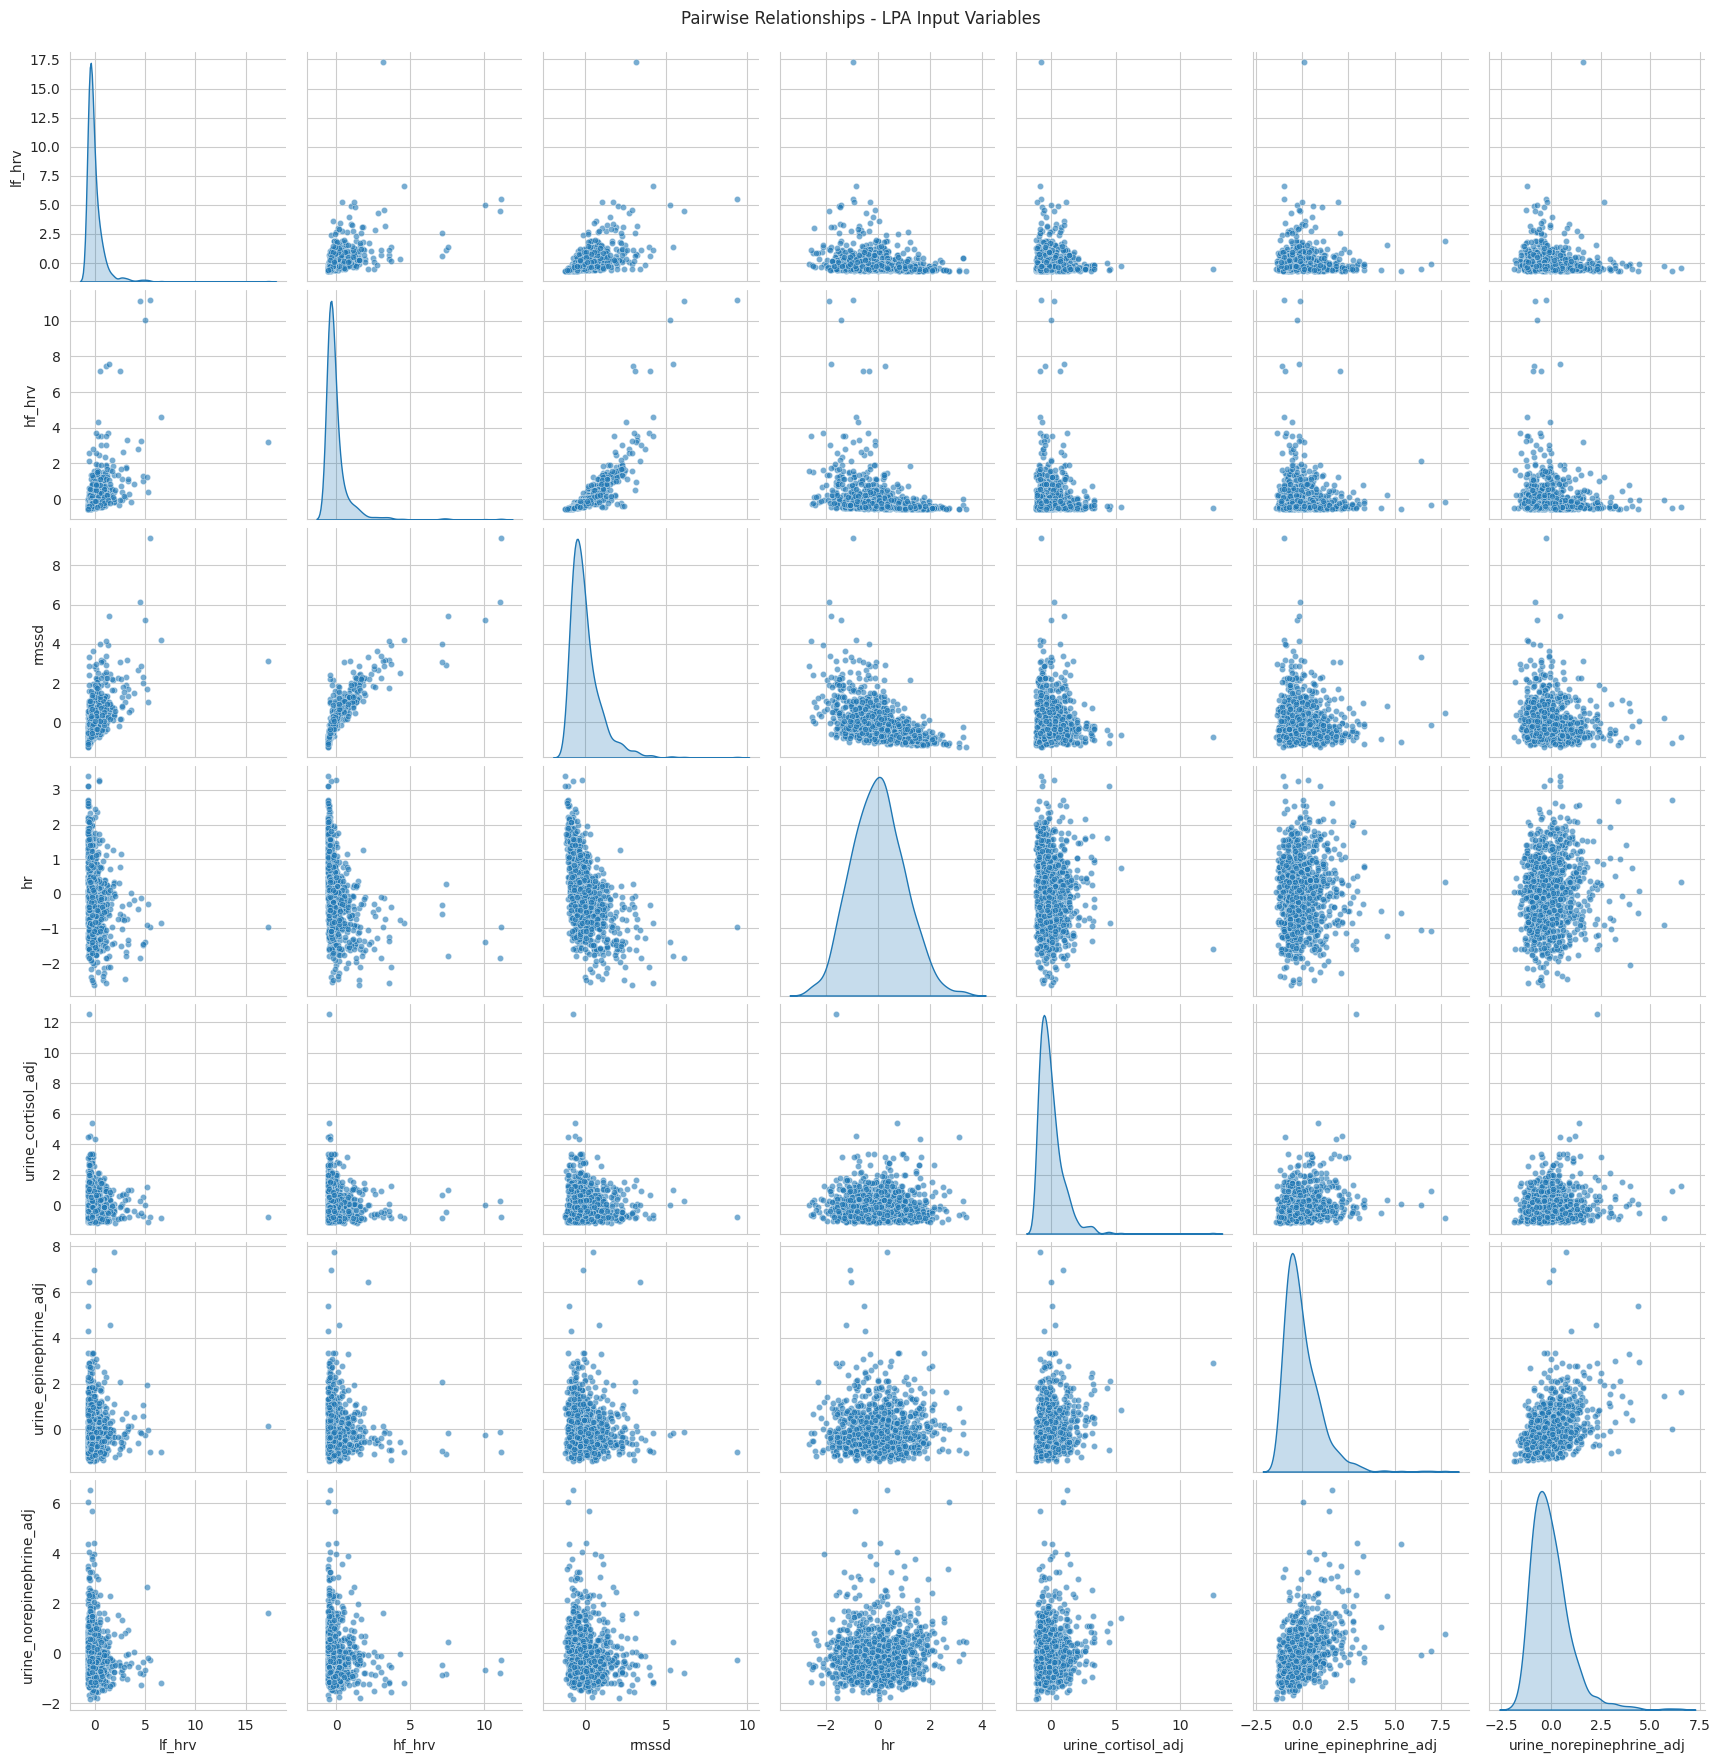

In [ ]:
plot_pairwise_scatters(data, lpa_input_vars)

## 1.2 Most/Least Common Patterns

In [ ]:
def analyze_variable_patterns(df, variables, threshold_percentile=90):
    """
    Identify most and least common patterns in input variables
    """
    results = {}

    for var in variables:
        # High values (top 10%)
        high_threshold = df[var].quantile(threshold_percentile/100)
        n_high = (df[var] >= high_threshold).sum()

        # Low values (bottom 10%)
        low_threshold = df[var].quantile(1 - threshold_percentile/100)
        n_low = (df[var] <= low_threshold).sum()

        # Middle values
        n_middle = len(df) - n_high - n_low

        results[var] = {
            'High (top 10%)': n_high,
            'Low (bottom 10%)': n_low,
            'Middle (10-90%)': n_middle,
            'High_threshold': high_threshold,
            'Low_threshold': low_threshold
        }

    pattern_df = pd.DataFrame(results).T
    print("\nVariable Range Distribution:")
    print(pattern_df)

    return pattern_df



In [ ]:
pattern_summary = analyze_variable_patterns(data, lpa_input_vars)


Variable Range Distribution:
                          High (top 10%)  Low (bottom 10%)  Middle (10-90%)  \
lf_hrv                             103.0             103.0            824.0   
hf_hrv                             103.0             103.0            824.0   
rmssd                              103.0             103.0            824.0   
hr                                 103.0             103.0            824.0   
urine_cortisol_adj                 107.0             105.0            818.0   
urine_epinephrine_adj              103.0             107.0            820.0   
urine_norepinephrine_adj           103.0             103.0            824.0   

                          High_threshold  Low_threshold  
lf_hrv                          0.807325      -0.587929  
hf_hrv                          0.740097      -0.504235  
rmssd                           1.122867      -0.873471  
hr                              1.342195      -1.274125  
urine_cortisol_adj              1.181608      -

#

# Part 2: LPA Model Comparison & Selection

## 2.1 Model Fit Statistics Comparison
Purpose: Compare 6-10 class solutions to identify best-fitting models

In [ ]:
!pip install py-latent-profiles
import os
import pickle
import re
import py_lpa as pylpa
from py_lpa import GaussianMixture

In [ ]:
import os
import pickle
import re
import py_lpa as pylpa
from py_lpa import GaussianMixture

# Define the path to the directory containing the .pkl files
profiles_dir = '/content/drive/MyDrive/MIDUS 2/Data/profiles_K_1_to_10/'

model_results = {}

# Iterate through the files in the directory
for filename in os.listdir(profiles_dir):
    if filename.endswith('.pkl'):
        # Extract the number of classes (K) from the filename
        match = re.search(r'profile_(\d+).pkl', filename)
        if match:
            k_classes = int(match.group(1))
            filepath = os.path.join(profiles_dir, filename)
            with open(filepath, 'rb') as f:
                # Load the GaussianMixture model object
                model = pickle.load(f)
                # Extract relevant fit statistics by calling their methods
                model_results[k_classes] = {
                    'AIC': model.AIC(),
                    'BIC': model.BIC(),
                    'SABIC': model.SABIC(),
                    'CAIC': model.CAIC(), # Added CAIC
                    'LogLik': model.log_likelihoods[-1] # Re-adding LogLik extraction
                }
            print(f"Loaded {filename} and extracted statistics for K={k_classes}")
        else:
            print(f"Could not extract K from filename: {filename}")

# Ensure the keys are sorted for consistent comparison
model_results = dict(sorted(model_results.items()))

print(f"Successfully loaded results for {len(model_results)} different class solutions.")
# print(model_results.keys())

Loaded profile_1.pkl and extracted statistics for K=1
Loaded profile_2.pkl and extracted statistics for K=2
Loaded profile_3.pkl and extracted statistics for K=3
Loaded profile_4.pkl and extracted statistics for K=4
Loaded profile_5.pkl and extracted statistics for K=5
Loaded profile_6.pkl and extracted statistics for K=6
Loaded profile_7.pkl and extracted statistics for K=7
Loaded profile_8.pkl and extracted statistics for K=8
Loaded profile_9.pkl and extracted statistics for K=9
Loaded profile_10.pkl and extracted statistics for K=10
Successfully loaded results for 10 different class solutions.


In [ ]:
def create_model_comparison_table(model_results):
    """
    Create comprehensive model fit comparison table

    Parameters:
    -----------
    model_results : dict
        Dictionary with keys as number of classes (6-10)
        Values are dicts containing: 'AIC', 'BIC', 'SABIC'
    """
    comparison_df = pd.DataFrame(model_results).T
    comparison_df.index.name = 'N_Classes'


    # Delta BIC and AIC
    comparison_df['Delta_BIC'] = comparison_df['BIC'] - comparison_df['BIC'].min()
    comparison_df['Delta_AIC'] = comparison_df['AIC'] - comparison_df['AIC'].min()
    # The LogLik column is already present from model_results, no need to recalculate.



    print(comparison_df.to_string())
    comparison_df.to_csv('lpa_model_comparison.csv')

    return comparison_df

In [ ]:
comparison_table = create_model_comparison_table(model_results)

                    AIC           BIC         SABIC          CAIC                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    LogLik    Delta_BIC    Delta_AIC
N_Classes                                                                                                                                                                                                                         

## 2.2 Visualization of Model Fit Indices


In [ ]:
def plot_fit_indices(comparison_df):
    """
    Visualize model fit indices across different class solutions
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6)) # Changed to 1 row, 2 columns

    # AIC/BIC/SABIC
    ax1 = axes[0] # Adjusted index
    ax1.plot(comparison_df.index, comparison_df['AIC'], marker='o', label='AIC', linewidth=2)
    ax1.plot(comparison_df.index, comparison_df['BIC'], marker='s', label='BIC', linewidth=2)
    ax1.plot(comparison_df.index, comparison_df['SABIC'], marker='^', label='SABIC', linewidth=2)
    ax1.set_xlabel('Number of Classes', fontsize=12)
    ax1.set_ylabel('Information Criterion', fontsize=12)
    ax1.set_title('Information Criteria by Number of Classes', fontsize=13, weight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Delta BIC
    ax3 = axes[1] # Adjusted index
    ax3.bar(comparison_df.index, comparison_df['Delta_BIC'], color='steelblue',
            alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Number of Classes', fontsize=12)
    ax3.set_ylabel('Δ BIC from Best Model', fontsize=12)
    ax3.set_title('BIC Difference from Best Fitting Model', fontsize=13, weight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('lpa_model_fit_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

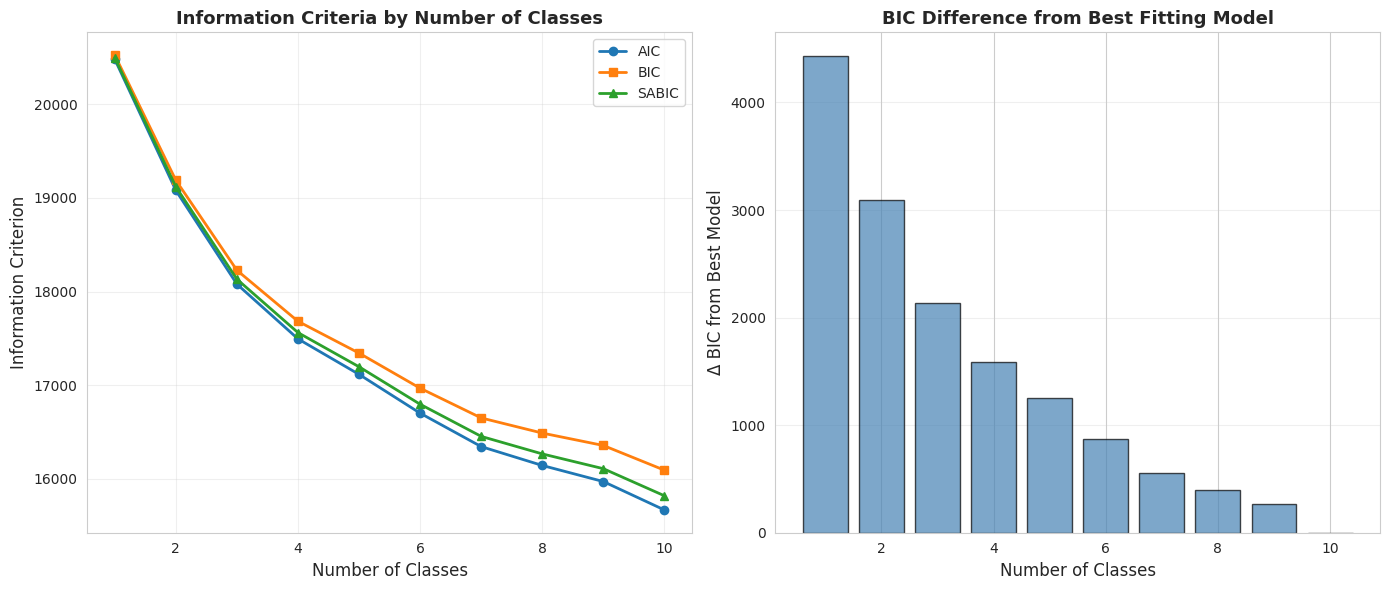

In [ ]:
plot_fit_indices(comparison_table)

In [ ]:
all_fit_stats = []
for k_val, stats_dict in model_results.items():
    fit_stats = {
        'K': k_val,
        'AIC': stats_dict['AIC'],
        'BIC': stats_dict['BIC'],
        'SABIC': stats_dict['SABIC'],
        'CAIC': stats_dict['CAIC'],
        'LogLik': stats_dict['LogLik'] if 'LogLik' in stats_dict else None # Handle case if LogLik not always present
    }
    all_fit_stats.append(fit_stats)

print("all_fit_stats has been successfully created:")
print(pd.DataFrame(all_fit_stats).to_string(index=False))

all_fit_stats has been successfully created:
 K          AIC          BIC        SABIC         CAIC                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   LogLik
 1 20479.093649 20523.529476 20494.944450 20532.529476                                                                                                                                                                     

In [ ]:
# ----------------------------------------------------------------------------
# STEP 2: MODEL SELECTION USING FIT INDICES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("STEP 2: Model Selection (Section 4.2 approach)")
print("="*80)

# Create comparison table
fit_df = pd.DataFrame(all_fit_stats)

print("\nFit Statistics Comparison:")
print(fit_df.to_string(index=False))

# Identify best K by BIC (primary criterion)
best_idx = fit_df['BIC'].idxmin()
best_K = int(fit_df.loc[best_idx, 'K'])
best_bic = fit_df.loc[best_idx, 'BIC']

print(f"\n{'─'*80}")
print("MODEL SELECTION DECISION (following Section 4.2):")
print(f"{'─'*80}")
print(f"Best K by BIC: {best_K} profiles")
print(f"BIC value: {best_bic:.2f}")

# Check for elbow point
print("\nElbow plot inspection:")
print("(Look for plateau in improvement)")
for i in range(len(fit_df)):
    k = int(fit_df.loc[i, 'K'])
    bic = fit_df.loc[i, 'BIC']
    marker = " <-- SELECTED" if k == best_K else ""
    print(f"  K={k}: BIC={bic:.2f}{marker}")


STEP 2: Model Selection (Section 4.2 approach)

Fit Statistics Comparison:
 K          AIC          BIC        SABIC         CAIC                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   LogLik
 1 20479.093649 20523.529476 20494.944450 20532.529476                                                                                                                                      

In [ ]:
# ----------------------------------------------------------------------------
# STEP 3: EXTRACT BEST MODEL & ASSIGNMENTS
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("STEP 3: Extracting Best Model Parameters")
print("="*80)

# Re-load the best model object (GaussianMixture instance) from its pickle file
# Assuming profiles_dir is defined and contains profile_{K}.pkl files
import pickle
import os

best_model_filepath = os.path.join(profiles_dir, f'profile_{best_K}.pkl')
with open(best_model_filepath, 'rb') as f:
    best_model = pickle.load(f)

# Extract parameters
means = best_model.means_
covariances = best_model.covariances_
proportions = best_model.pi_

print(f"\nProfile Means (shape: {means.shape}):")
print(means)

print(f"\nProfile Proportions:")
for i, prop in enumerate(proportions[0]):
    print(f"  Profile {i}: {prop:.3f} ({prop*100:.1f}%)的发展)")

# Define the indicators variable, as it was missing
indicators = data[lpa_input_vars].to_numpy()

# Get assignments
assignments = best_model.predict(indicators)[0]
probabilities = best_model.predict_proba(indicators)[0]

# Add to dataframe
df = data.copy()
df['profile_assignment'] = assignments
for i in range(best_K):
    df[f'prob_profile_{i}'] = probabilities[:, i]

# Profile sizes
profile_counts = pd.Series(assignments).value_counts().sort_index()

print(f"\nProfile Sizes:")
for profile_num, count in profile_counts.items():
    pct = (count / len(assignments)) * 100
    print(f"  Profile {profile_num}: n = {count:4d} ({pct:5.1f}%) ")

# Classification quality check
print(f"\nSample Assignments (first 10 participants):")
sample_cols = ['profile_assignment'] + [f'prob_profile_{i}' for i in range(best_K)]
print(df[sample_cols].head(10).to_string(index=False))


STEP 3: Extracting Best Model Parameters

Profile Means (shape: (1, 10, 7)):
[[[-3.25101461e-01 -3.75445266e-01 -5.30282487e-01  3.57588590e-01
   -8.76120482e-02 -1.92194223e-01 -1.44207065e-01]
  [ 1.57063698e+00  3.21741493e+00  3.21280000e+00 -1.04336871e+00
   -2.74723452e-01 -6.27060312e-01 -7.59488767e-01]
  [ 1.40957941e+00  7.33780157e+00  3.86478188e+00 -6.10588545e-01
    1.00460489e-01 -1.53420112e-02 -4.45408653e-01]
  [-3.61012354e-01 -3.73811578e-01 -5.02100979e-01  3.64497672e-01
    5.12234667e-01  1.32453558e+00  1.24248229e+00]
  [ 1.04721982e-01 -3.98915100e-02  3.98495357e-01 -5.06747545e-01
    1.65377264e+00  3.50360181e+00  3.26875886e+00]
  [ 5.00128256e+00  1.07579569e+01  6.90607000e+00 -1.41204409e+00
   -1.63452539e-01 -4.51909787e-01 -5.74000597e-01]
  [ 1.80909942e-01  1.84202914e-02  3.84409052e-01 -5.14737012e-01
   -8.61773704e-02 -3.02737770e-01 -2.75179003e-01]
  [ 1.47882830e+00  1.55507457e+00  1.98054033e+00 -1.11307507e+00
    4.97197916e-02  1.

In [ ]:
# ----------------------------------------------------------------------------
# STEP 4: COMPUTE ENTROPY (not built-in, manual calculation)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("STEP 4: Classification Quality (Entropy)")
print("="*80)

def entropy_from_probs(probs):
    """Calculate entropy (Section 4.2 mentions this indirectly)"""
    eps = 1e-15
    p = np.clip(probs, eps, 1.0)
    n, K = p.shape
    if K == 1:
        return 1.0
    ent = -np.sum(p * np.log(p)) / (n * np.log(K))
    return 1.0 - ent

entropy = entropy_from_probs(probabilities)

print(f"\nEntropy: {entropy:.3f}")
if entropy >= 0.80:
    print("  ✓ Excellent separation (≥ 0.80)")
elif entropy >= 0.70:
    print("  ✓ Good separation (≥ 0.70)")
elif entropy >= 0.60:
    print("  ⚠ Acceptable separation (≥ 0.60)")
else:
    print("  ✗ Poor separation (< 0.60)")
    print("  Consider: Reducing K or different constraints")


STEP 4: Classification Quality (Entropy)

Entropy: 0.980
  ✓ Excellent separation (≥ 0.80)


In [ ]:
# ----------------------------------------------------------------------------
# STEP 5: BOOTSTRAP STANDARD ERRORS (Optional)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("STEP 5: Computing Standard Errors (Section 3.3)")
print("="*80)

print("\nComputing bootstrap standard errors (this may take a few minutes)...")
print("Using parametric bootstrap with 100 samples...")

try:
    std_errors = best_model.bootstrap_fitted(indicators, nbs=100)

    print("\n✓ Bootstrap complete")
    print("\nStandard Errors:")
    print(f"  Proportions SE: {std_errors[0]}")
    print(f"  Means SE (shape {std_errors[1].shape}):")
    print(f"    {std_errors[1]}")

except Exception as e:
    print(f"\n✗ Bootstrap failed: {e}")
    print("  (This is optional; proceeding without SEs)")


STEP 5: Computing Standard Errors (Section 3.3)

Computing bootstrap standard errors (this may take a few minutes)...
Using parametric bootstrap with 100 samples...


  0%|          | 0/100 [01:45<?, ?it/s]


KeyboardInterrupt: 


STEP 6: Visualizing Profiles


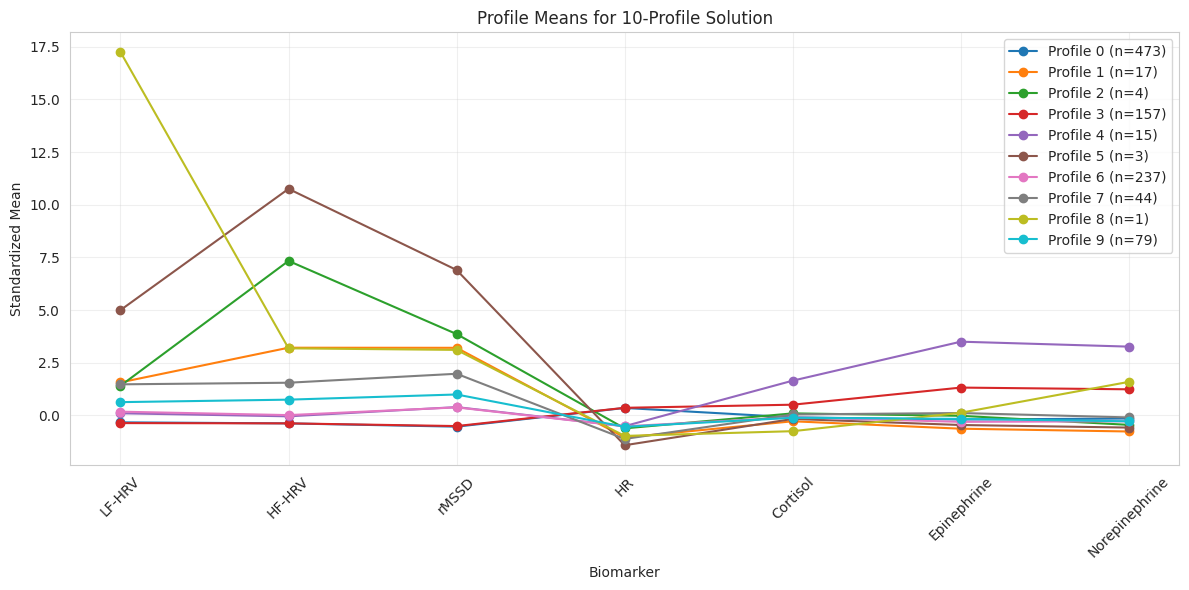


✓ Profile visualization complete


In [ ]:
# ----------------------------------------------------------------------------
# STEP 6: VISUALIZE PROFILES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("STEP 6: Visualizing Profiles")
print("="*80)

# Create profile means plot
biomarker_names = ['LF-HRV', 'HF-HRV', 'rMSSD', 'HR',
                   'Cortisol', 'Epinephrine', 'Norepinephrine']

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(best_K):
    profile_means = means[0, i, :]
    ax.plot(biomarker_names, profile_means, marker='o',
            label=f'Profile {i} (n={profile_counts[i]})')

ax.set_xlabel('Biomarker')
ax.set_ylabel('Standardized Mean')
ax.set_title(f'Profile Means for {best_K}-Profile Solution')
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n✓ Profile visualization complete")

In [ ]:
# ----------------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("LPA COMPLETE - FINAL SUMMARY")
print("="*80)
print(f"Selected Solution: K = {best_K} profiles")
print(f"Model Specification: Local independence + cross-class equality")
print(f"BIC: {best_bic:.2f}")
print(f"Entropy: {entropy:.3f}")
print(f"Profile Distribution: {dict(profile_counts)}")

print("="*80)

# Store results
best_fit_model = {
    'model': best_model,
    'K': best_K,
    'BIC': best_bic,
    'entropy': entropy,
    'assignments': assignments,
    'probabilities': probabilities,
    'means': means,
    'proportions': proportions,
    'profile_sizes': dict(profile_counts)
}

print("\n✓ Results stored in 'best_fit_model' dictionary")
print("✓ Profile assignments added to 'df' dataframe")


LPA COMPLETE - FINAL SUMMARY
Selected Solution: K = 10 profiles
Model Specification: Local independence + cross-class equality
BIC: 16092.87
Entropy: 0.980
Profile Distribution: {0: np.int64(473), 1: np.int64(17), 2: np.int64(4), 3: np.int64(157), 4: np.int64(15), 5: np.int64(3), 6: np.int64(237), 7: np.int64(44), 8: np.int64(1), 9: np.int64(79)}

✓ Results stored in 'best_fit_model' dictionary
✓ Profile assignments added to 'df' dataframe


In [ ]:
# save best fit model in /Data
import pickle
with open('/content/drive/MyDrive/MIDUS 2/Data/best_fit_model_02172026.pkl', 'wb') as f:
    pickle.dump(best_fit_model, f)
    print("✓ best_fit_model saved")

✓ best_fit_model saved


# Visualize profiles

### Visualize latetnt profiles function


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

"""
we need to allign the variables
"""


def visualize_latent_profiles( df,
                               profile_col,
                               indicator_variables = [
                                   'lf_hrv',
                                    'hf_hrv',
                                    'rmssd',
                                    'hr',
                                    'urine_cortisol_adj',
                                    'urine_epinephrine_adj',
                                    'urine_norepinephrine_adj'],
                              #  outcome_variables = ['depression_i',
                              #                       'anxiety_trait',
                              #                       'general_distress_anxious',
                              #                       'depression_pa',
                              #                       'anger_trait',
                              #                       'phys_hlth_evnts_tot']

                               outcome_variables = [
                     'anxiety',
                     'distress_anxious',
                     'anger',
                     'depression',
                     'phys_hlth_evnts_tot',
                     'cvd_risk'
                     ]

                              #  outcome_variables = ['depression_total',
                              #                       'anxiety_trait',
                              #                       'general_distress_anxious',
                              #                       'depression_pa',
                              #                       'anger_trait',
                              #                       'phys_hlth_evnts_tot']
                              , show = ("sizes",
                                        "heatmap",
                                        "bar",
                                        "box_facet_profile_indicators",
                                        "box_facet_profile_outcomes" ,
                                        "violin_facet_profile_indicators",
                                        "violin_facet_profile_outcomes",
                                        "bar.T",
                                        "box_facet_indicator_profile",
                                        "box_facet_outcomes_profile",
                                        "violin_facet_indicators_profile" ,
                                        "violin_facet_outcomes_profile"
                                        )
                              , print_tables = False



                              ):


  # ---- handle non-existing profile and indicator and outcome columns --------#

  if profile_col not in df.columns:
    raise ValueError(f"'{profile_col}' not found in dataframe columns.")

  vars_all = list(indicator_variables) + list(outcome_variables)
  missing = [c for c in vars_all if c not in df.columns]
  if missing:
    raise ValueError(f"Missing columns in df: {missing}")

  # ---------------------------------------------------------------------------#

  d = df.copy()


  # ------------------------ get profiles stats -------------------------------#

  size_counts = d[profile_col].value_counts().sort_index()
  size_df = pd.DataFrame({"n": size_counts})
  size_df["pct"] = size_df["n"] / size_df["n"].sum() * 100

  if print_tables:
    print(size_df)

  #
  grouped = d.groupby(profile_col)
  mean_df = grouped[vars_all].mean(numeric_only=True)
  std_df = grouped[vars_all].std(numeric_only=True)

  raw_summary = pd.concat(
        {"mean": mean_df, "std": std_df, "n": grouped.size()},
        axis=1
  )

  if print_tables:
    print(raw_summary)

  # ---------------------------------------------------------------------------#



  # --------------------------- prep long data --------------------------------#

  indicators_long = d[[profile_col] + list(indicator_variables)].melt(
        id_vars=[profile_col],
        var_name="indicator",
        value_name="value"
    )
  outcomes_long = d[[profile_col] + list(outcome_variables)].melt(
        id_vars=[profile_col],
        var_name="outcome",
        value_name="value"
    )
  # ---------------------------------------------------------------------------#





  # ---------------------------------------------------------------------------#
  # --------------------------- dashboard -------------------------------------
  # ---------------------------------------------------------------------------#

  figs = {}

  figsize_dashboard = (14, 9)
  palette="Set1"


  # ---------- sizes ----------

  if "sizes" in show:
    fig, ax = plt.subplots(figsize=(6, 4))

    tmp = size_df.reset_index().rename(columns={"index": profile_col})
    sns.barplot(data=tmp, x=profile_col, y="n", ax=ax, palette=palette)
    ax.set_title("Profile sizes")
    ax.set_xlabel("Profile")
    ax.set_ylabel("Count")
    for i, row in tmp.iterrows():
      ax.text(i, row["n"], f'{int(row["n"])}\n({row["pct"]:.1f}%)', ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    figs["sizes"] = fig




    # tmp = size_df.reset_index().rename(columns={"index": profile_col})
    # fig = px.bar(
    #             tmp,
    #             x=profile_col,
    #             y="n",
    #             text=tmp.apply(lambda r: f'{int(r["n"])} ({r["pct"]:.1f}%)', axis=1),
    #             title="Profile sizes",
    #         )
    # fig.update_traces(textposition="outside")
    # fig.update_layout(yaxis_title="Count", xaxis_title="Profile")
    # figs["sizes"] = fig



  # ---------- heatmaps ----------
  if "heatmap" in show:

    # ---- indicators ----
    fig, ax =plt.subplots(figsize=(6, 4))
    sns.heatmap(
                mean_df[indicator_variables],
                annot=True,
                fmt=".2f",
                cmap="RdBu_r",
                ax=ax
            )
    ax.set_title("-------------Indicators: (standardized) mean by profile -------------")
    ax.set_xlabel("Indicator")
    ax.set_ylabel("Profile")
    plt.tight_layout()
    figs["heatmap_indicators"] = fig

    # ---- outcomes ----
    fig, ax =plt.subplots(figsize=(6, 4))
    sns.heatmap(
                mean_df[outcome_variables],
                annot=True,
                fmt=".2f",
                cmap="RdBu_r",
                ax=ax
            )
    ax.set_title("-------------Outcomes: mean by profile-------------")
    ax.set_xlabel("Outcome")
    ax.set_ylabel("Profile")
    plt.tight_layout()
    figs["heatmap_outcomes"] = fig

  # ---------------------------------------------------------------------------#
  # ------------------- x indicator/outcome , col profile --------------------

  if "bar" in show:
    # ---- indicators ----
    fig, ax =plt.subplots(figsize=(6, 4))
    mean_df[indicator_variables].plot(kind="bar", ax=ax)
    ax.set_ylabel("Standardized mean")
    ax.set_title("Indicators by latent profile (mean)")
    # ax.set_xticklabels(ax.get_xticklabels , rotation=90)
    plt.tight_layout()
    figs["bar_indicators"] = fig

    # ---- outcomes ----
    fig, ax =plt.subplots(figsize=(6, 4))

    mean_df[outcome_variables].plot(kind="bar", ax=ax)
    ax.set_ylabel("Mean outcome variable values")
    ax.set_title("-------------Outcomes by latent profile (mean) - do we want to standardize outcomes as well?")
    # ax.set_xticklabels([str(p) for p in order], rotation=0)
    plt.tight_layout()
    figs["bar_outcomes"] = fig


    # ---------- box facet by profile indicators ----------
    if "box_facet_profile_indicators" in show:
      g = sns.catplot(
                data=indicators_long,
                x="indicator",
                y="value",
                kind="box",
                col=profile_col,
                col_wrap=3, # TODO: check this
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
      g.fig.suptitle("-------------Indicator distributions (box) by profile-------------", y=1.03)
      for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=90)
      figs["box_facet_profile_indicators"] = g.fig


  # ---------- box facet by outcomes ----------
  if "box_facet_profile_outcomes" in show:
    g = sns.catplot(
                data=outcomes_long,
                x="outcome",
                y="value",
                kind="box",
                col=profile_col,
                col_wrap=7,
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
    g.fig.suptitle("-------------Outcome distributions (box) - by profile-------------", y=1.03)

    for ax in g.axes.flatten():
      ax.tick_params(axis="x", rotation=90)
    figs["box_facet_profile_outcomes"] = g.fig




    # ---------- violin facet by profile indicators ----------
    if "violin_facet_profile_indicators" in show:
      g = sns.catplot(
                data=indicators_long,
                x="indicator",
                y="value",
                kind="violin",
                col=profile_col,
                col_wrap=3, # TODO: check this
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
      g.fig.suptitle("-------------Indicator distributions (violin) by profile-------------", y=1.03)
      for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=90)
      figs["violin_facet_profile_indicators"] = g.fig


  # ---------- violin facet by outcomes ----------
  if "violin_facet_profile_outcomes" in show:
    g = sns.catplot(
                data=outcomes_long,
                x="outcome",
                y="value",
                kind="violin",
                col=profile_col,
                col_wrap=7,
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
    g.fig.suptitle("-------------Outcome distributions (violin) - by profile-------------", y=1.03)

    for ax in g.axes.flatten():
      ax.tick_params(axis="x", rotation=90)
    figs["violin_facet_profile_outcomes"] = g.fig



  # ---------------------------------------------------------------------------#



  # ---------------------------------------------------------------------------#
  # ------------------- x profile , col indicator/outcome --------------------

  if "bar.T" in show:
    # ---- indicators ----
    fig, ax =plt.subplots(figsize=(6, 4))
    mean_df[indicator_variables].T.plot(kind="bar", ax=ax)
    ax.set_ylabel("Standardized mean")
    ax.set_title("------------- Indicators by latent profile (mean) -------------")
    # ax.set_xticklabels(ax.get_xticklabels , rotation=90)
    plt.tight_layout()
    figs["bar_indicators"] = fig

    # ---- outcomes ----
    fig, ax =plt.subplots(figsize=(6, 4))

    # print("MMMMMMMMMMMMMMMMMMMMMMMMMMMMMMMM")
    # print(mean_df[outcome_variables])

    mean_df[outcome_variables].T.plot(kind="bar", ax=ax)
    ax.set_ylabel("Mean outcome variable values")
    ax.set_title("-------------Outcomes by latent profile (mean) -------------")
    # ax.set_xticklabels([str(p) for p in order], rotation=0)
    plt.tight_layout()
    figs["bar_outcomes"] = fig


    # ---------- box facet by profile indicators ----------
    if "box_facet_indicator_profile" in show:
      g = sns.catplot(
                data=indicators_long,
                x=profile_col,
                y="value",
                kind="box",
                col="indicator",
                col_wrap=3, # TODO: check this
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
      g.fig.suptitle("-------------Profile indicator distributions (box) by indicator-------------", y=1.03)
      for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=90)
      figs["box_facet_indicator_profile"] = g.fig


  # ---------- box facet by profile outcomes ----------
  if "box_facet_outcomes_profile" in show:
    g = sns.catplot(
                data=outcomes_long,
                x=profile_col,
                y="value",
                kind="box",
                col="outcome",
                col_wrap=7,
                palette=palette,
                height=4,
                aspect=1,
                sharey=False
            )
    g.fig.suptitle("-------------Profile outcome distributions (box) - by outcome-------------", y=1.03)

    for ax in g.axes.flatten():
      ax.tick_params(axis="x", rotation=90)
    figs["box_facet_outcomes_profile"] = g.fig



#
    # ---------- violin facet by profile indicators ----------
    if "violin_facet_indicators_profile" in show:
      g = sns.catplot(
                data=indicators_long,
                x=profile_col,
                y="value",
                kind="violin",
                col="indicator",
                col_wrap=3, # TODO: check this
                palette=palette,
                height=4,
                aspect=1,
                sharey=True
            )
      g.fig.suptitle("-------------Profile indicator distributions (violin) by indicators-------------", y=1.03)
      for ax in g.axes.flatten():
        ax.tick_params(axis="x", rotation=90)
      figs["violin_facet_indicators_profile"] = g.fig


  # ---------- violin facet by outcomes ----------
  if "violin_facet_outcomes_profile" in show:
    g = sns.catplot(
                data=outcomes_long,
                x=profile_col,
                y="value",
                kind="violin",
                col="outcome",
                col_wrap=7,
                palette=palette,
                height=4,
                aspect=1,
                sharey=False
            )
    g.fig.suptitle("-------------Profile outcome distributions (violin) - by outcome-------------", y=1.03)

    for ax in g.axes.flatten():
      ax.tick_params(axis="x", rotation=90)
    figs["violin_facet_outcomes_profile"] = g.fig








    return {
        "size_df": size_df,
        "mean_df": mean_df,
        "std_df": std_df,
        "raw_summary": raw_summary,
        "indicators_long": indicators_long,
        "outcomes_long": outcomes_long,
        "figs": figs,
    }






  # ---------------------------------------------------------------------------#
  # ---------------------------------------------------------------------------#
  # ---------------------------------------------------------------------------#
  # ---------------------------------------------------------------------------#
  # ---------------------------------------------------------------------------#
  # ---------------------------------------------------------------------------#


# y_predicted =lpa.predict(indicators)[0].tolist()

# lpa_variables['profiles_lpa_3'] = y_predicted

# res = visualize_latent_profiles(lpa_variables, 'profiles_lpa_3',
#                                         show = ("sizes",
#                                         "heatmap",
#                                         "bar",
#                                         "box_facet_profile_indicators",
#                                         "box_facet_profile_outcomes" ,
#                                         "violin_facet_profile_indicators",
#                                         "violin_facet_profile_outcomes",
#                                         "bar.T",
#                                         "box_facet_indicator_profile",
#                                         "box_facet_outcomes_profile",
#                                         "violin_facet_indicators_profile" ,
#                                         "violin_facet_outcomes_profile"
#                                 )

# )

-----------------------------------------------------------------------
-----------------------------------------------------------------------
-----------------------------------------------------------------------
-----------------------------------------------------------------------
------------------------Profile Visualizations------------------------
-----------------------------------------------------------------------
-----------------------------------------------------------------------
-----------------------------------------------------------------------
-----------------------------------------------------------------------


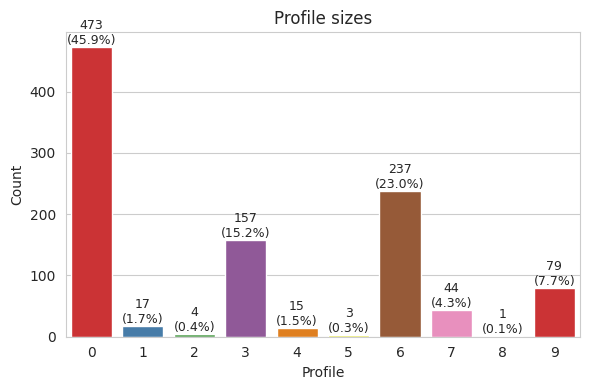

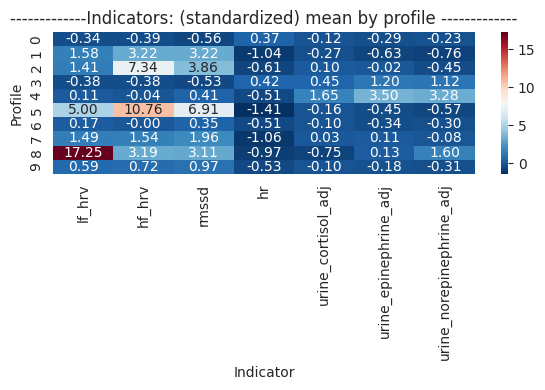

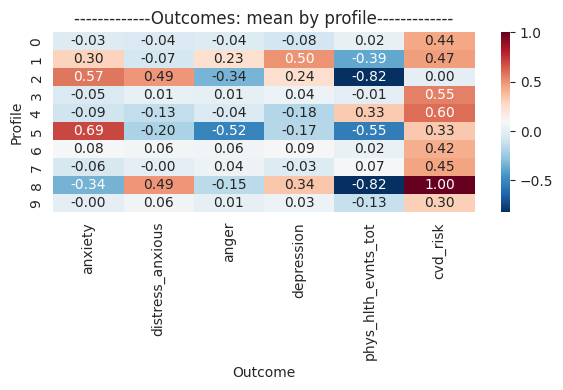

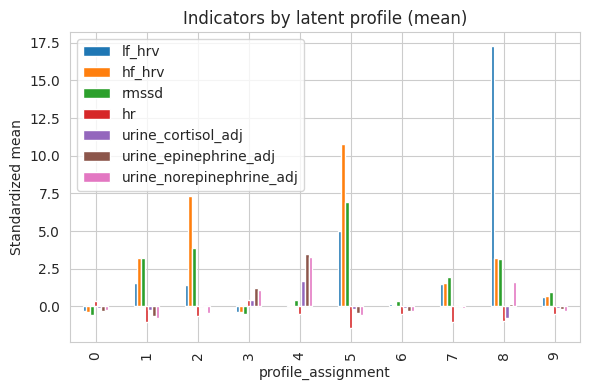

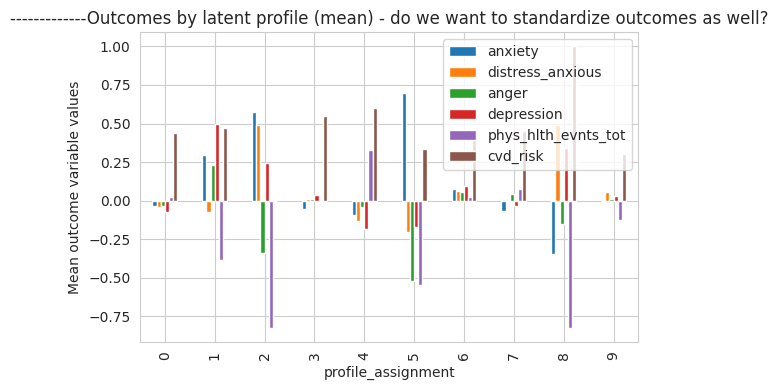

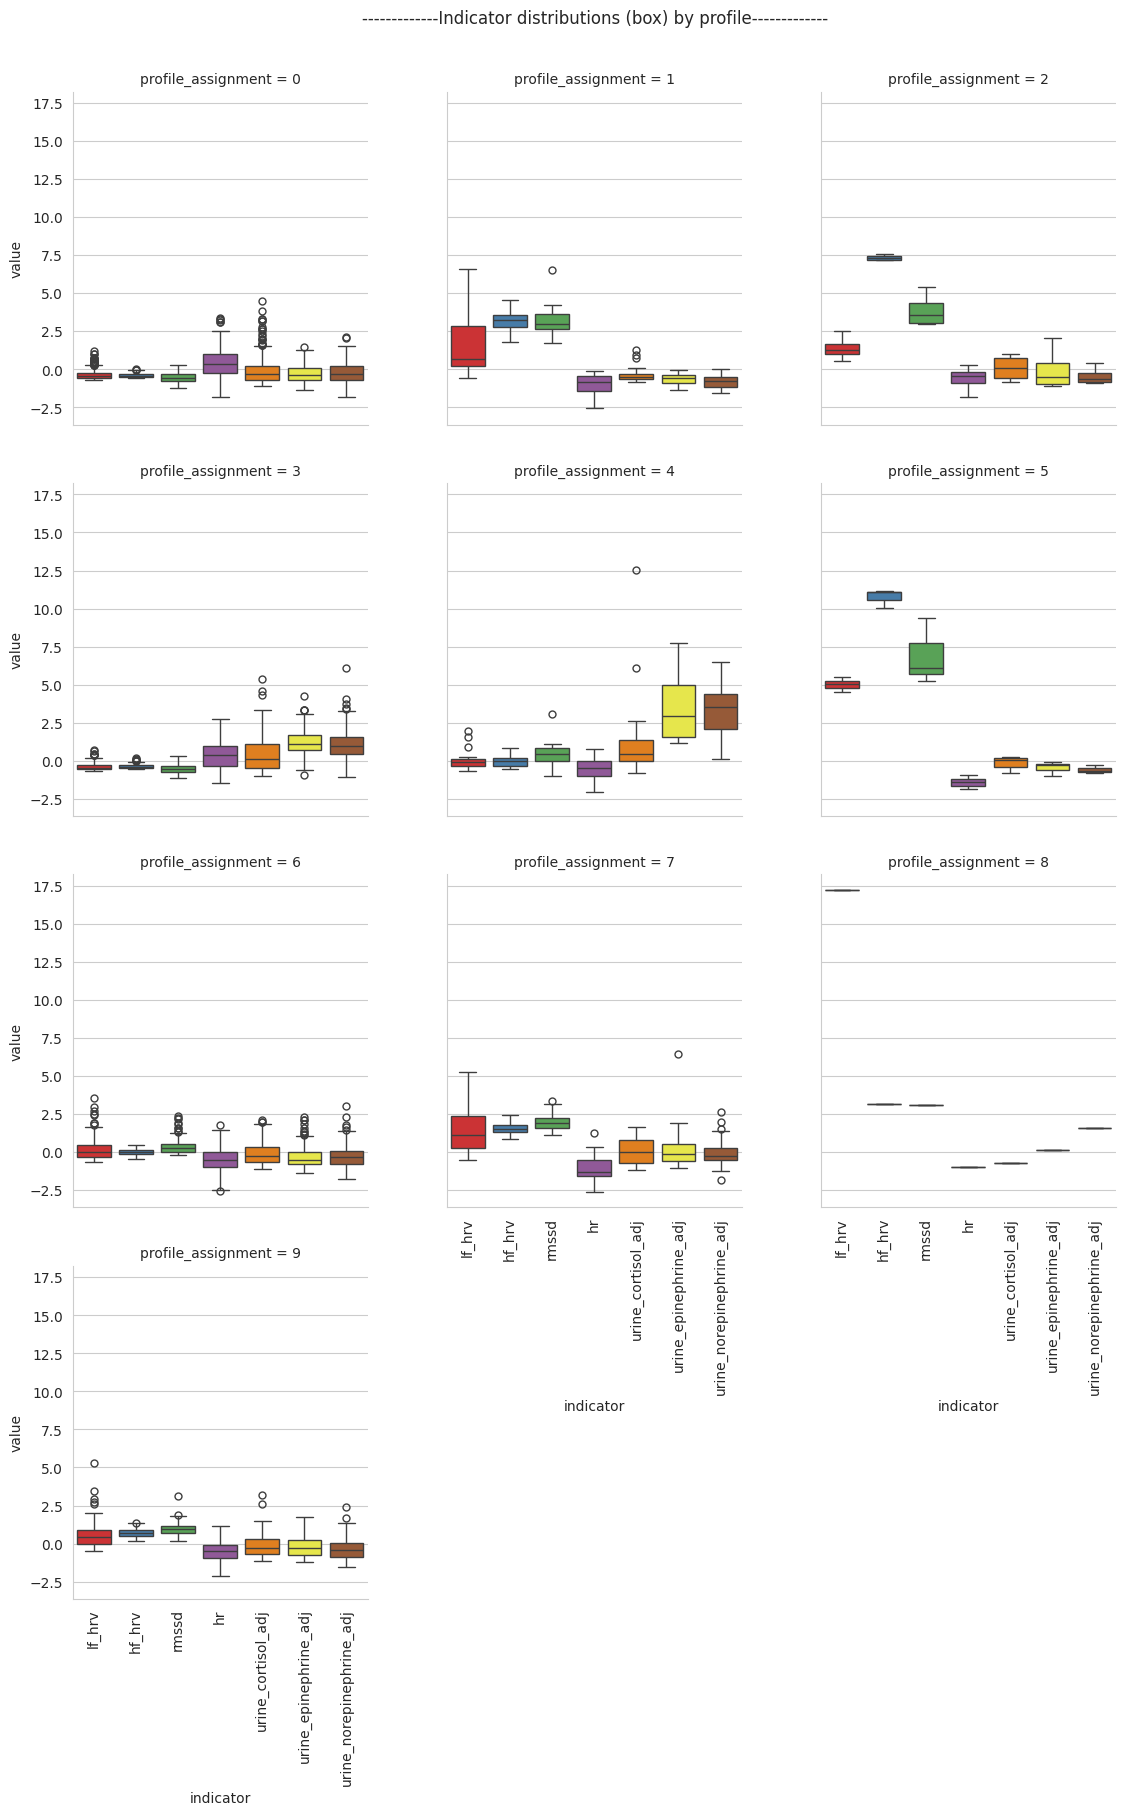

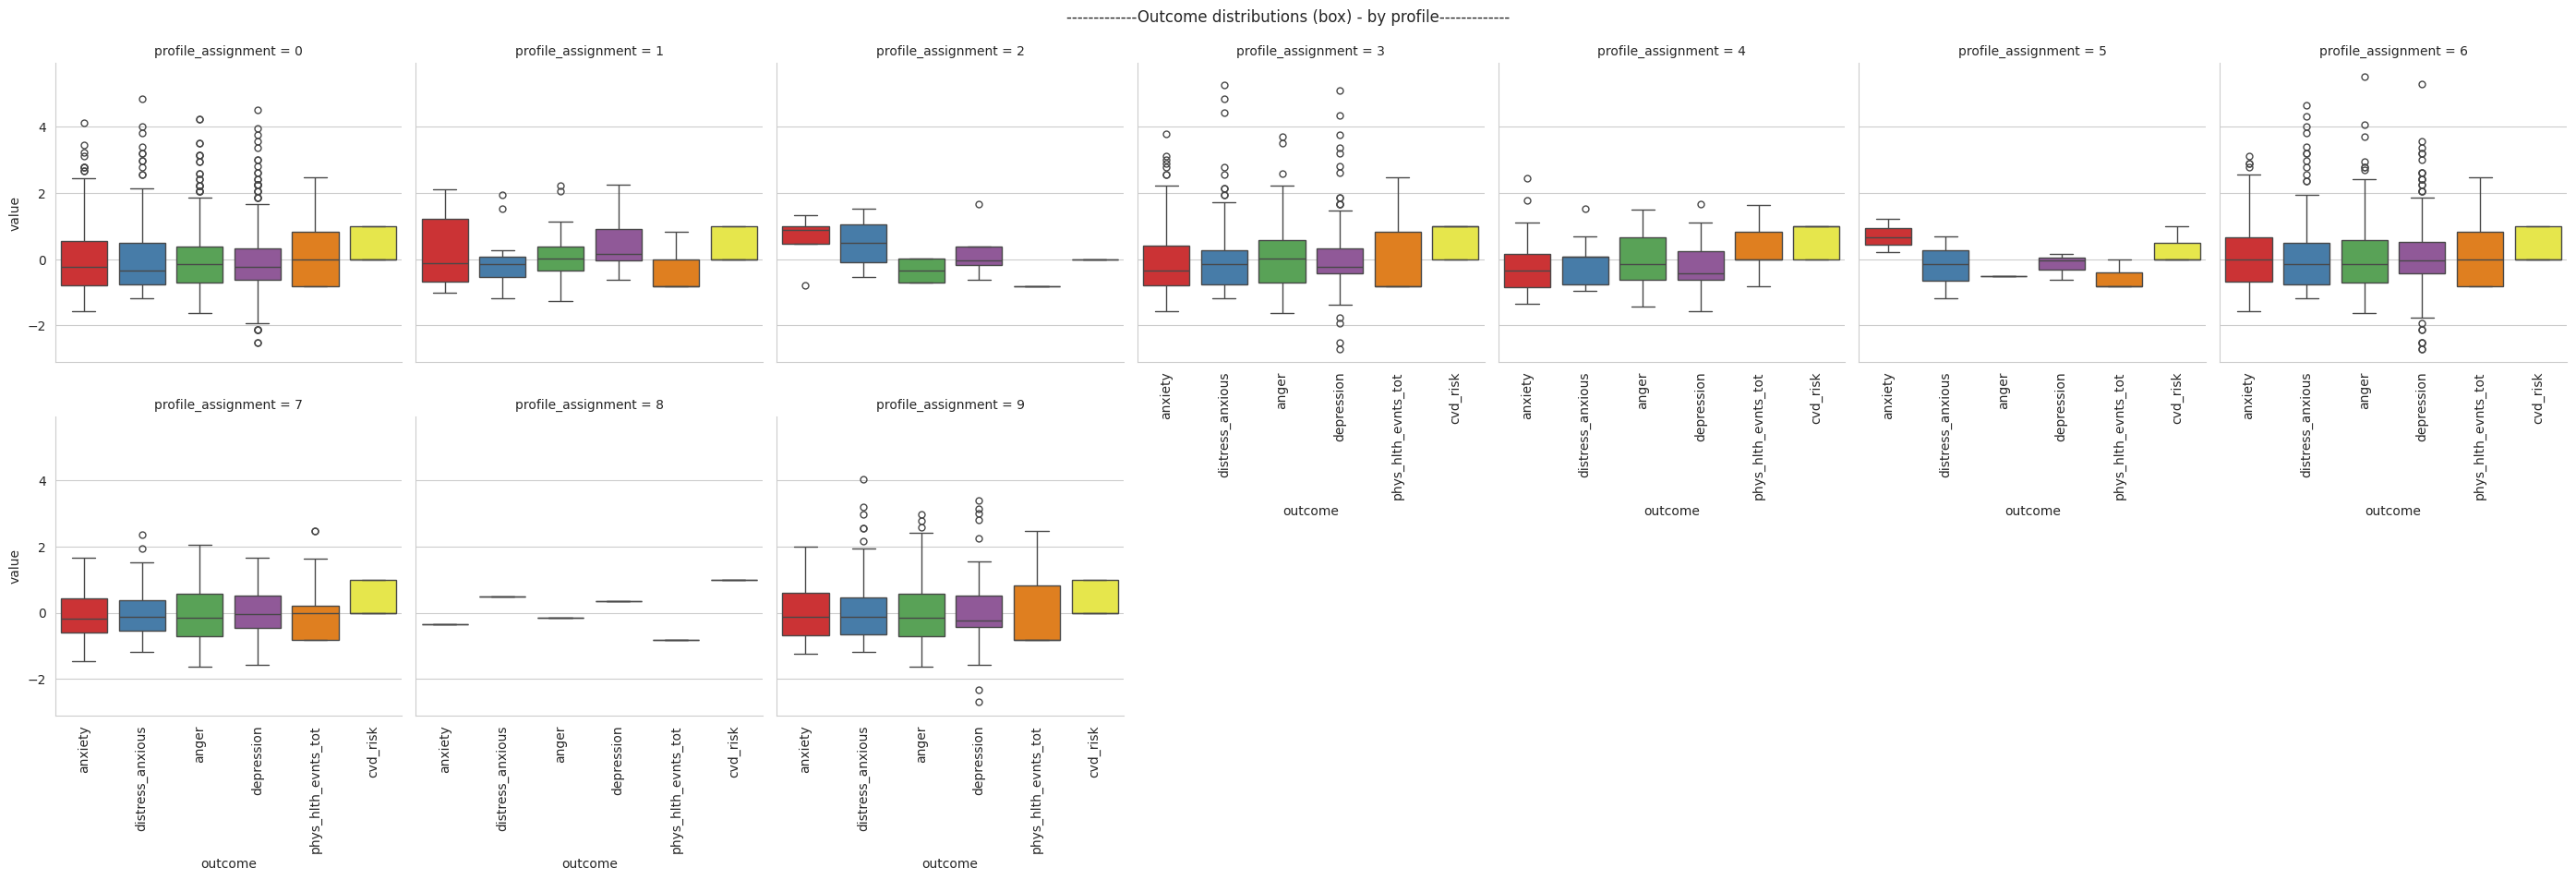

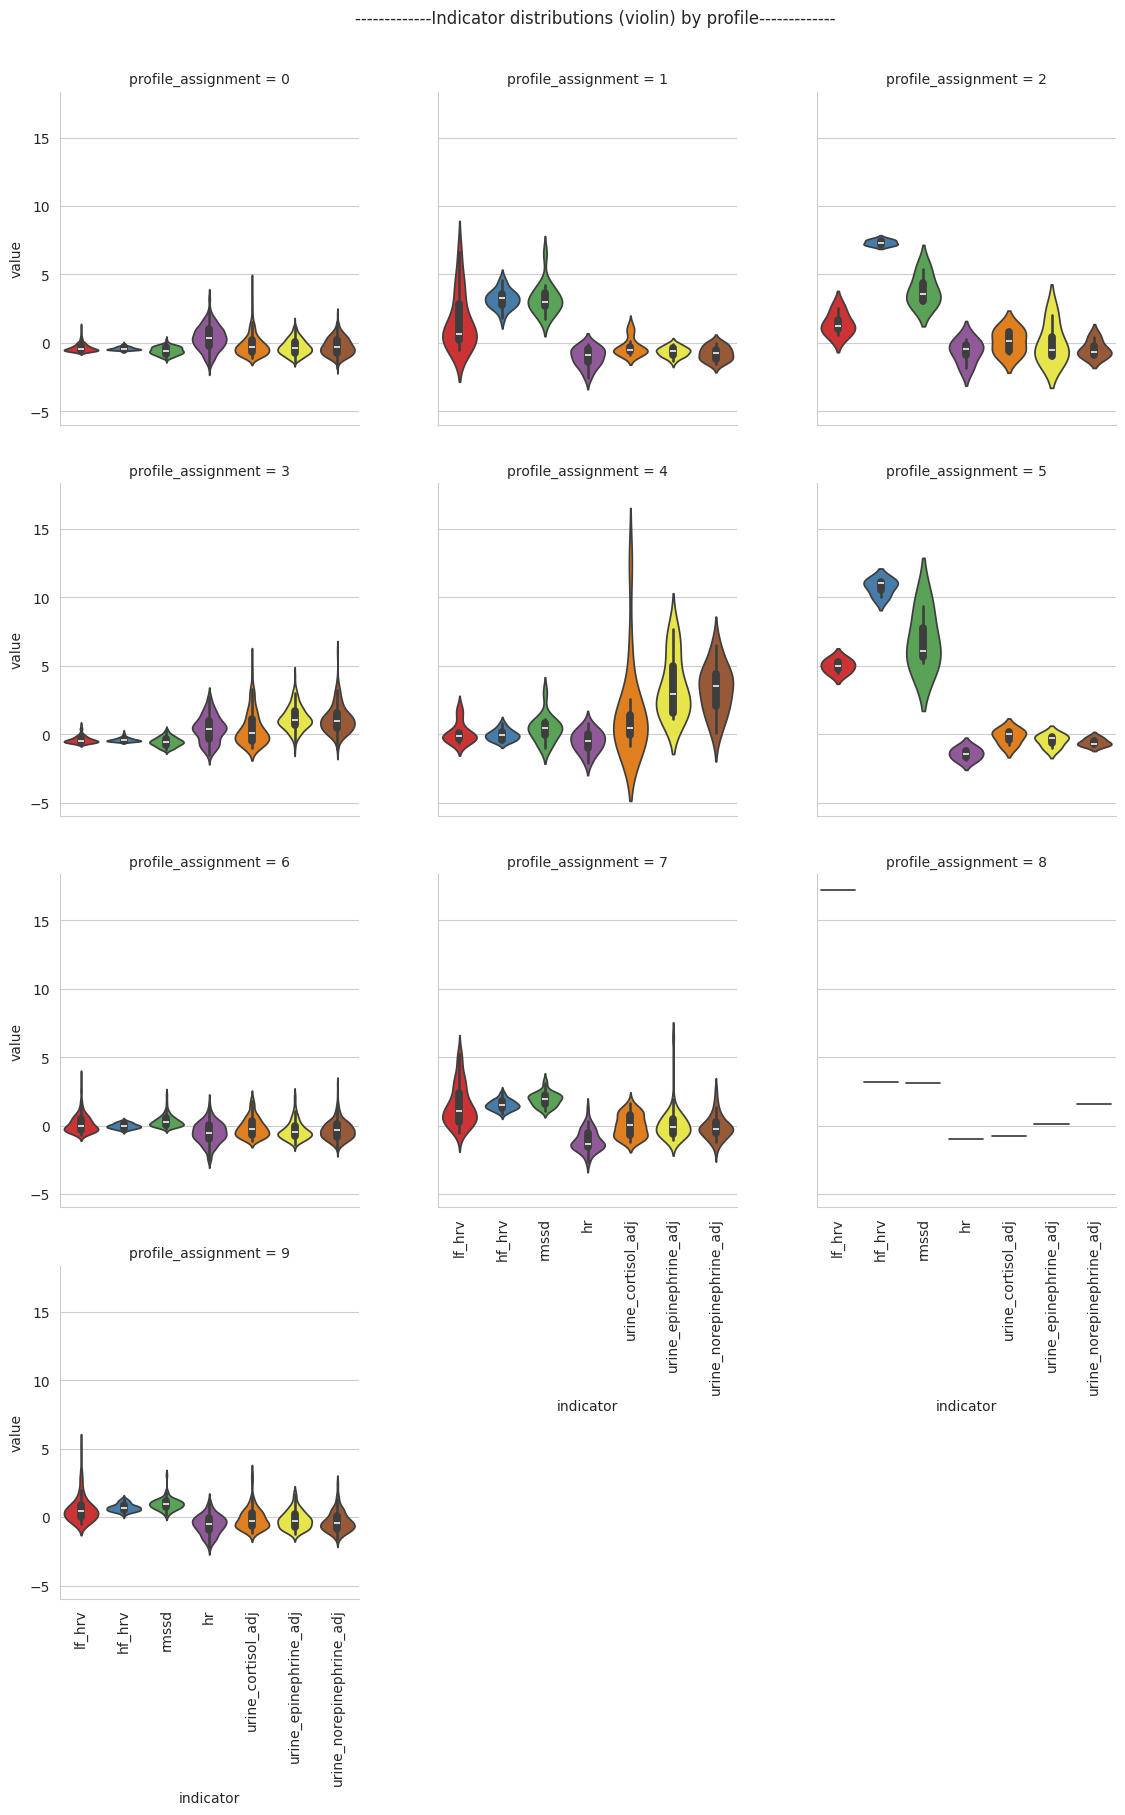

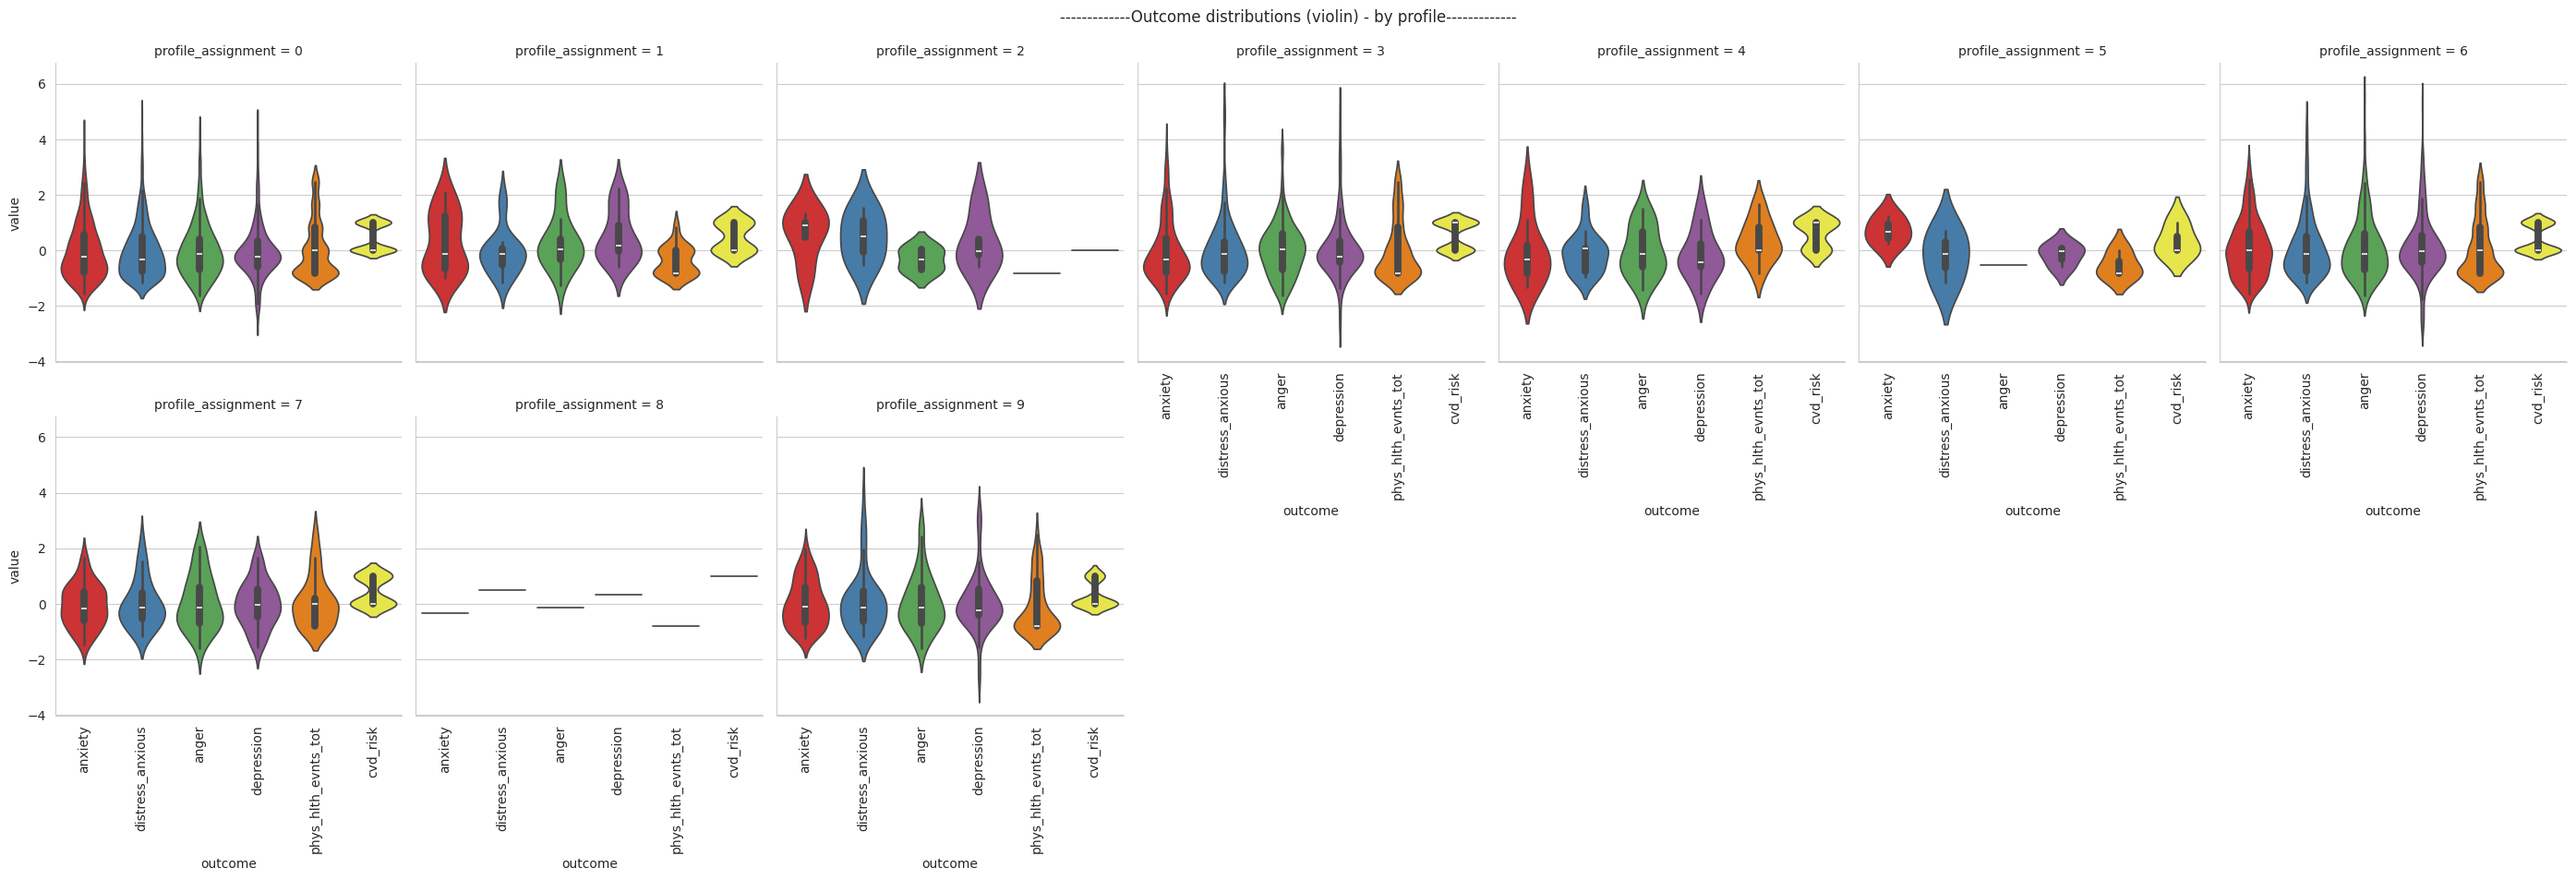

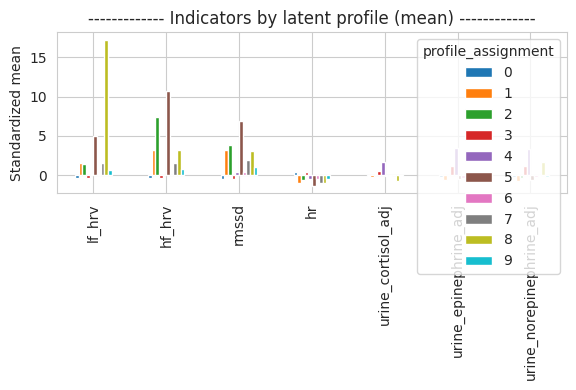

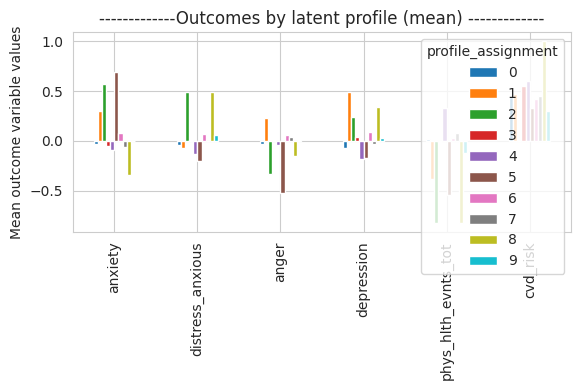

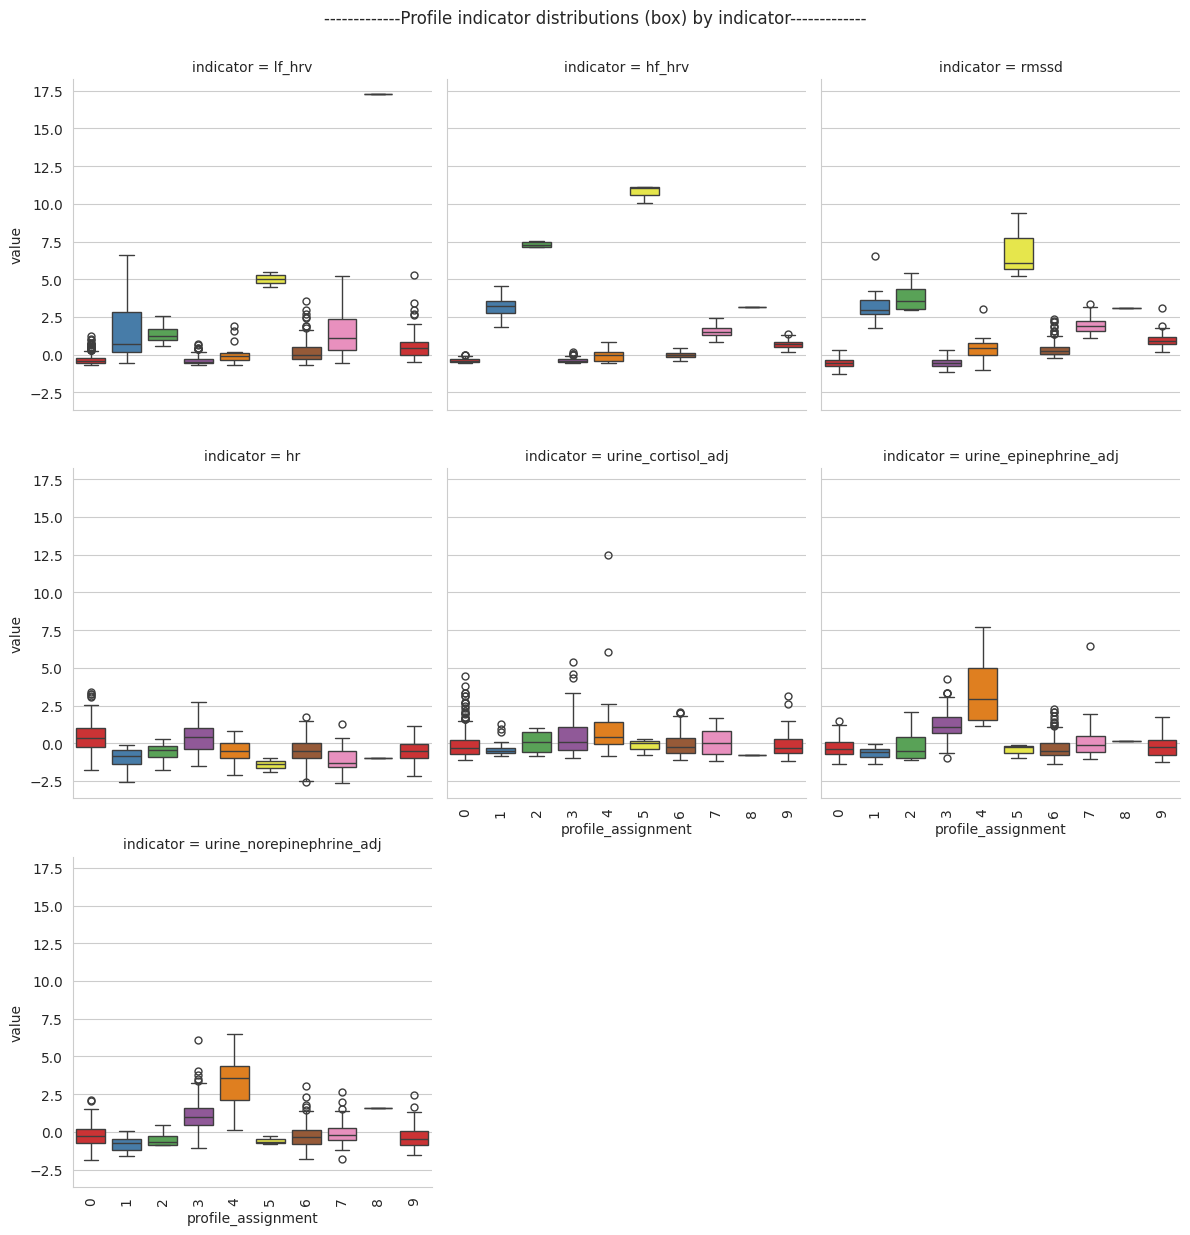

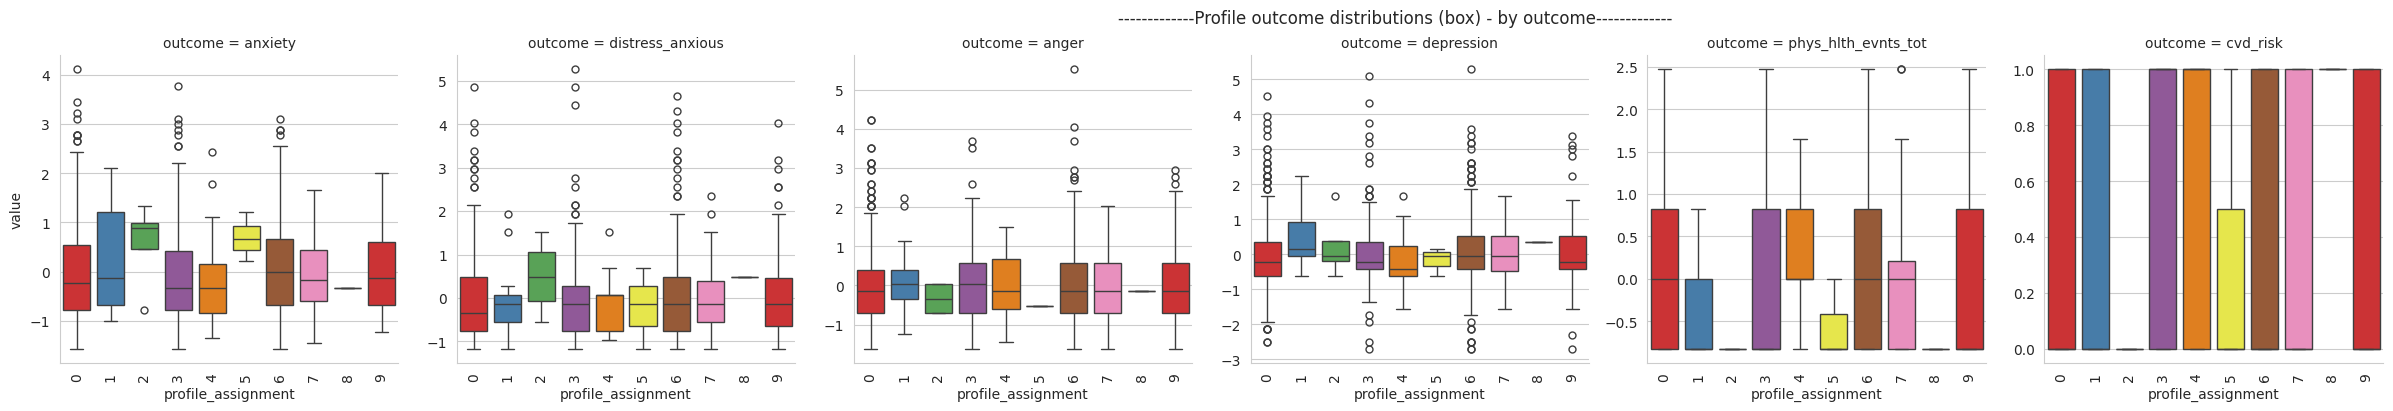

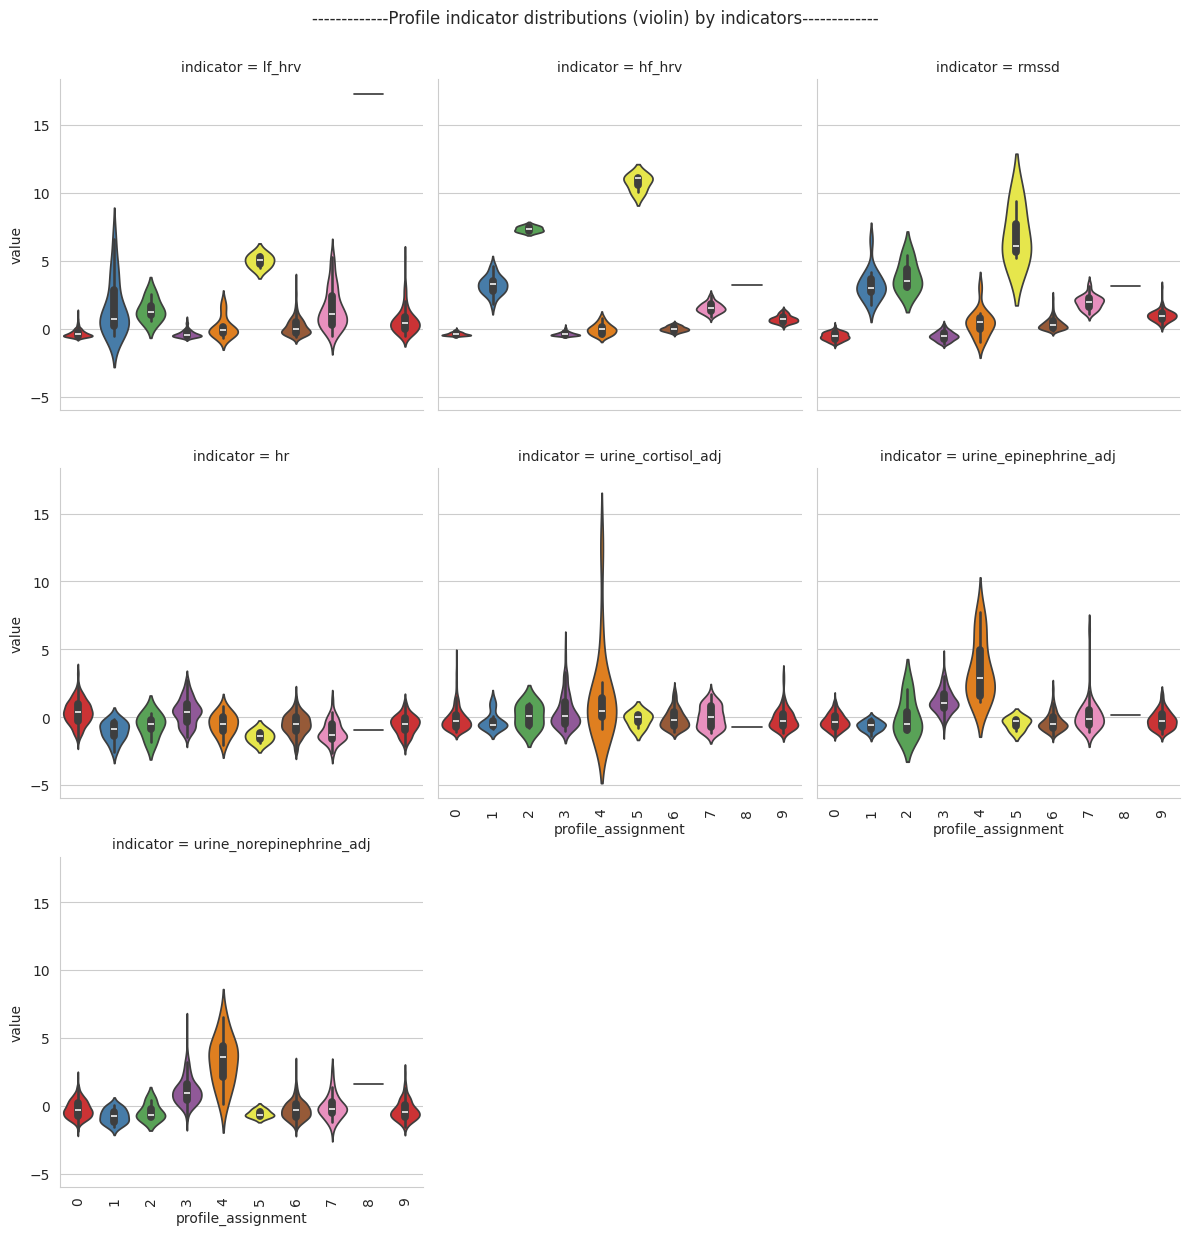

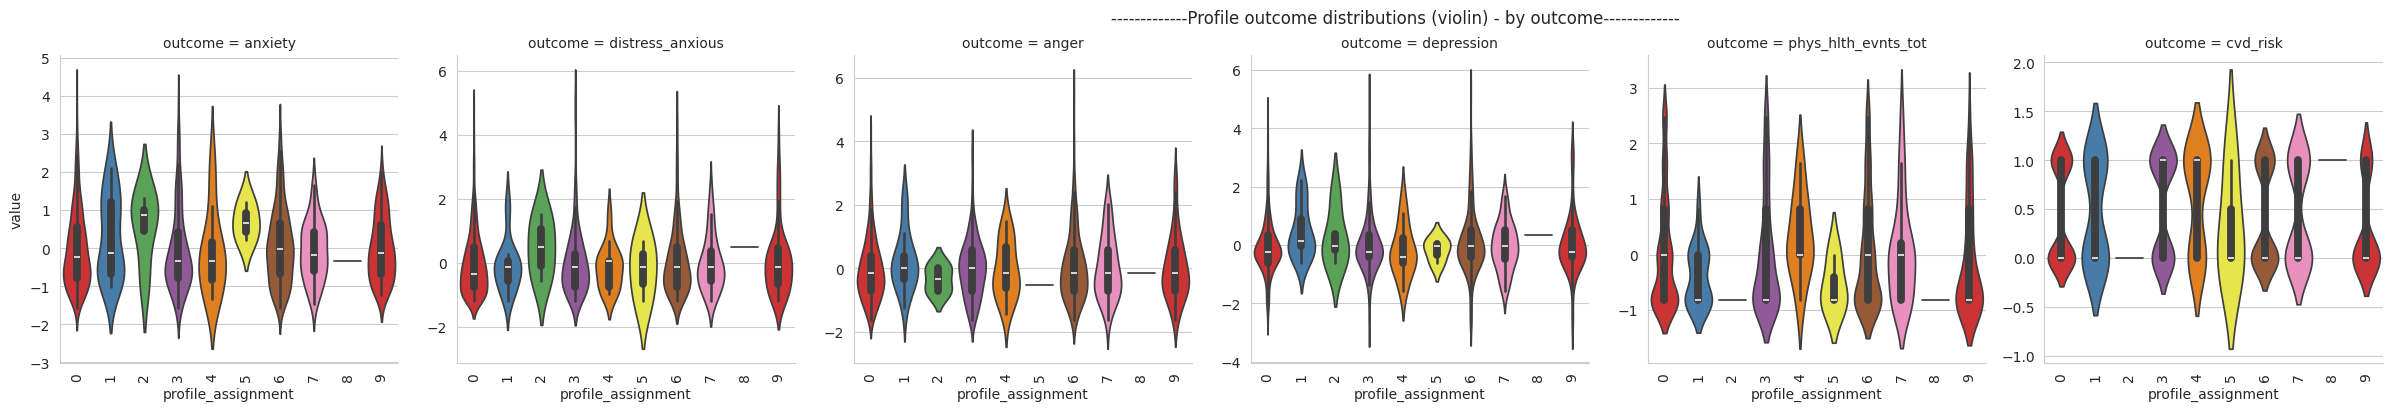

In [ ]:
# Ensure necessary variables are available. If the kernel was restarted,
# 'data' and 'indicators' should be loaded/generated from preceding cells.
# 'best_fit_model' is loaded from its saved state.
import pickle
import pandas as pd # Ensure pandas is imported if kernel restarts
import py_lpa # Import py_lpa to unpickle the model
from py_lpa import GaussianMixture # Explicitly import GaussianMixture

# Load the best_fit_model from the pickle file
# Assumes 'best_fit_model_02172026.pkl' has been created by previous steps (cell bAKE0XWrDb1R).
try:
    with open('/content/drive/MyDrive/MIDUS 2/Data/best_fit_model_02172026.pkl', 'rb') as f:
        loaded_best_fit_model = pickle.load(f)
    best_model = loaded_best_fit_model['model']
    best_K = loaded_best_fit_model['K']
except FileNotFoundError:
    print("Error: 'best_fit_model_02172026.pkl' not found. Please ensure the model fitting and saving steps were completed successfully.")
    # If the file is not found, we cannot proceed with visualization; stopping here for clarity.
    raise

# Re-define indicator_variables and outcome_varialbes for robustness if kernel was reset
indicator_variables = ['lf_hrv', 'hf_hrv', 'rmssd', 'hr', 'urine_cortisol_adj', 'urine_epinephrine_adj', 'urine_norepinephrine_adj']
outcome_varialbes = ['anxiety', 'distress_anxious', 'anger', 'depression', 'phys_hlth_evnts_tot', 'cvd_risk']

# Ensure 'data' and 'indicators' are defined from prior cells.
# If a NameError for 'data' or 'indicators' occurs, please run the cells where they are defined
# (e.g., cell OPWjpp34H2sU for 'data' and cell w4a9KsUDOlzF for 'indicators').

# Get assignments
indicators = data[lpa_input_vars].to_numpy()
assignments = best_model.predict(indicators)[0]
probabilities = best_model.predict_proba(indicators)[0]

# Add to dataframe
df = data.copy()
df['profile_assignment'] = assignments
for i in range(best_K):
    df[f'prob_profile_{i}'] = probabilities[:, i]

print("-----------------------------------------------------------------------")
print("-----------------------------------------------------------------------")
print("-----------------------------------------------------------------------")


# visualize them
print("-----------------------------------------------------------------------")
print(f"------------------------Profile Visualizations------------------------")
print("-----------------------------------------------------------------------")

res = visualize_latent_profiles(df, 'profile_assignment',
                                      indicator_variables=indicator_variables,
                                      outcome_variables=outcome_varialbes,
                                      show = ("sizes",
                                      "heatmap",
                                      "bar",
                                      "box_facet_profile_indicators",
                                      "box_facet_profile_outcomes" ,
                                      "violin_facet_profile_indicators",
                                      "violin_facet_profile_outcomes",
                                      "bar.T",
                                      "box_facet_indicator_profile",
                                      "box_facet_outcomes_profile",
                                      "violin_facet_indicators_profile" ,
                                      "violin_facet_outcomes_profile"
                              )

)


print("-----------------------------------------------------------------------")
print("-----------------------------------------------------------------------")
print("-----------------------------------------------------------------------")